# Data Analysis — LOB Market Manipulation Detection

This notebook works through six analysis angles for the project. They will be filled in one section at a time:

1. **Univariate distributions** — *(implemented in this notebook)*
2. Train vs. val vs. test distributional comparison
3. Per-symbol heterogeneity
4. Temporal coverage and event-rate patterns
5. Joint feature structure (correlations + 2-D embeddings)
6. Domain primer + manipulation-pattern fingerprints

---

## 1. Univariate Distributions

Goal: understand what each column **looks like on its own** — its range, central tendency, shape, and pathological patterns (mass spikes, missing values, etc.). Anomaly detection means modelling "normal", so we need to know what normal looks like one feature at a time before we can detect deviations.

Sub-steps:
- **1.1** Descriptive statistics (`describe`) per split.
- **1.2** Summary of categorical and temporal columns.
- **1.3** Top-5 most-common values per numeric column (mass-spike detection).
- **1.4** Histograms — linear-scale (focused on the bulk) and symlog-scale (showing tails) — for every numeric feature.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 90

### Load the three datasets

In [2]:
train = pd.read_csv('train_data.csv')
val   = pd.read_csv('val_data.csv')
test  = pd.read_csv('test_data.csv')

print(f'train: {train.shape}')
print(f'val:   {val.shape}')
print(f'test:  {test.shape}')

train: (1070022, 23)
val:   (467939, 23)
test:  (289101, 21)


### 1.1 Descriptive statistics per split

For every numeric column we report `count`, `mean`, `std`, `min`, the four quartiles, and `max`. The `count` row also surfaces missing values (compare to the dataset's row count).

In [3]:
for split_name, df in [('train', train), ('val', val), ('test', test)]:
    print(f'\n=== {split_name}  shape={df.shape} ===')
    display(df.describe(include=[np.number]).T)


=== train  shape=(1070022, 23) ===


,count,mean,std,min,25%,50%,75%,max
Time,"1,070,022.0000","127,592.8267","20,964.9834","93,121.0000","110,344.0000","130,756.0000","150,041.0000","160,349.0000"
MilliSeconds,"1,070,022.0000",498.7266,289.8963,0.0000,246.0000,499.0000,751.0000,999.0000
TimeInMilliSecs,"1,070,022.0000","46,719,097.7666","7,595,271.5202","34,281,175.0000","39,824,217.0000","47,276,115.0000","54,041,967.7500","57,829,051.0000"
OriginalSequenceNumber,"1,070,022.0000","164,084,227.7531","78,868,932.6205","30,890.0000","95,164,412.7500","172,342,921.0000","234,090,489.7500","287,173,095.0000"
ReturnBid1,"1,070,022.0000",0.0023,0.9173,-25.8411,-0.0019,-0.0002,0.0010,25.8430
ReturnAsk1,"1,070,022.0000",0.0177,0.3626,-9.0401,0.0090,0.0178,0.0235,9.0871
DerivativeReturnBid1,"1,070,022.0000",0.0078,0.9122,-36.2254,-0.0019,-0.0016,-0.0006,36.2134
DerivativeReturnAsk1,"1,070,022.0000",0.0141,0.3685,-10.1383,0.0076,0.0135,0.0263,7.8914
BidSize1,"1,070,022.0000",0.0397,0.9899,-1.2477,-0.3486,-0.1371,0.0889,29.2526
AskSize1,"1,070,022.0000",0.0260,1.0738,-1.3355,-0.4619,-0.1911,0.2118,52.4182



=== val  shape=(467939, 23) ===


,count,mean,std,min,25%,50%,75%,max
Time,"467,939.0000","128,071.9615","17,210.1073","93,059.0000","120,007.0000","125,034.0000","142,451.0000","160,000.0000"
MilliSeconds,"467,939.0000",499.6516,290.4528,0.0000,253.0000,501.0000,752.0000,999.0000
TimeInMilliSecs,"467,939.0000","46,834,636.2592","6,138,296.1989","34,259,280.0000","43,207,086.0000","46,234,153.0000","51,891,074.0000","57,600,996.0000"
OriginalSequenceNumber,"467,939.0000","165,793,145.9217","62,897,087.4704","857,798.0000","133,231,156.0000","165,642,738.0000","214,741,961.0000","282,630,080.0000"
ReturnBid1,"467,939.0000",0.0046,0.8311,-16.2670,-0.0019,-0.0016,0.0010,16.2638
ReturnAsk1,"467,939.0000",0.0185,0.3292,-5.3333,0.0090,0.0178,0.0235,5.3513
DerivativeReturnBid1,"467,939.0000",0.0104,0.8286,-16.7463,-0.0019,-0.0016,-0.0006,16.7431
DerivativeReturnAsk1,"467,939.0000",0.0142,0.3363,-6.0549,0.0076,0.0135,0.0263,6.0701
BidSize1,"467,939.0000",-0.0456,0.6638,-1.2431,-0.3501,-0.1449,0.0351,8.9252
AskSize1,"467,939.0000",-0.0642,0.6554,-1.3357,-0.4116,-0.1860,0.1649,17.0321



=== test  shape=(289101, 21) ===


,count,mean,std,min,25%,50%,75%,max
Time,"289,101.0000","119,263.4897","24,035.5318","93,000.0000","94,625.0000","113,455.0000","145,008.0000","160,350.0000"
MilliSeconds,"289,101.0000",495.4817,288.5523,0.0000,249.0000,490.0000,748.0000,999.0000
TimeInMilliSecs,"289,101.0000","43,688,574.2466","8,665,117.0675","34,200,005.0000","35,185,570.0000","41,695,820.0000","53,408,434.0000","57,830,619.0000"
ReturnBid1,"289,099.0000",0.0033,17.9836,-300.4934,-0.0017,-0.0017,-0.0005,300.4901
ReturnAsk1,"289,099.0000",0.0141,6.0676,-97.2636,0.0090,0.0090,0.0177,97.2817
DerivativeReturnBid1,"289,099.0000",-0.0014,3.1541,-58.1239,-0.0018,-0.0016,-0.0016,36.2413
DerivativeReturnAsk1,"289,099.0000",-0.0308,2.1174,-110.2013,0.0075,0.0078,0.0141,20.1132
BidSize1,"289,056.0000",-0.0707,1.1635,-1.2490,-0.6427,-0.1852,0.1150,30.5041
AskSize1,"289,056.0000",-0.0020,1.2625,-1.3336,-0.7072,-0.2097,0.3552,52.5355
TradeBidSize,"289,056.0000",-0.0108,1.4174,-0.2378,-0.1932,-0.1032,-0.0950,158.9021


### 1.2 Categorical & temporal column summaries

Columns that aren't standard numeric features get their own summary:
- `ExternalSymbol` (categorical) — value counts.
- `Date` (string with embedded session marker) — number of unique values + a few examples.
- `Time`, `MilliSeconds`, `TimeInMilliSecs` (integer-encoded timestamps) — dtype + range + uniqueness.
- `OriginalSequenceNumber`, `ID`, `index` — the identifier columns.
- `ClusterNo` and `TARGET` — special metadata columns (train/val only).

In [4]:
def cat_temporal_summary(df, name):
    print(f'\n========= {name}  shape={df.shape} =========')

    if 'ExternalSymbol' in df.columns:
        sym_vc = df['ExternalSymbol'].value_counts(dropna=False)
        print(f'\n  ExternalSymbol — {df["ExternalSymbol"].nunique()} unique:')
        for s, c in sym_vc.items():
            print(f'    {str(s):8s}  count={c:>10,}  pct={c/len(df)*100:>5.2f}%')

    if 'Date' in df.columns:
        d_vc = df['Date'].value_counts(dropna=False)
        print(f'\n  Date — {df["Date"].nunique()} unique values, examples: {list(d_vc.index[:5])}')

    print()
    for col in ['Time', 'MilliSeconds', 'TimeInMilliSecs']:
        if col in df.columns:
            s = df[col]
            print(f'  {col:18s} dtype={str(s.dtype):8s} min={s.min():>15} max={s.max():>15} n_unique={s.nunique():>10,}')

    print()
    for col in ['OriginalSequenceNumber', 'ID', 'index']:
        if col in df.columns:
            s = df[col]
            print(f'  {col:24s} dtype={str(s.dtype):8s} n_unique={s.nunique():>10,} sample={s.iloc[0]!r}')

    if 'ClusterNo' in df.columns:
        s = df['ClusterNo']
        print(f'\n  ClusterNo: dtype={s.dtype}, nulls={s.isnull().sum():,}/{len(df):,}, non_null_unique={s.dropna().nunique()}')

    if 'TARGET' in df.columns:
        print(f'  TARGET: unique values = {sorted(df["TARGET"].unique())}, dtype = {df["TARGET"].dtype}')

cat_temporal_summary(train, 'train')
cat_temporal_summary(val,   'val')
cat_temporal_summary(test,  'test')


========= train  shape=(1070022, 23) =========

  ExternalSymbol — 5 unique:
    INTC      count=   226,109  pct=21.13%
    MSFT      count=   224,561  pct=20.99%
    GOOG      count=   215,865  pct=20.17%
    AMZN      count=   212,912  pct=19.90%
    AAPL      count=   190,575  pct=17.81%



  Date — 777 unique values, examples: ['20120621.0-98', '20120621.0-376', '20120621.0-128', '20120621.0-150', '20120621.0-360']

  Time               dtype=int64    min=          93121 max=         160349 n_unique=    20,832
  MilliSeconds       dtype=int64    min=              0 max=            999 n_unique=     1,000
  TimeInMilliSecs    dtype=float64  min=     34281175.0 max=     57829051.0 n_unique=   216,550

  OriginalSequenceNumber   dtype=int64    n_unique=   322,336 sample=np.int64(48222841)
  ID                       dtype=int64    n_unique= 1,070,022 sample=np.int64(0)

  ClusterNo: dtype=float64, nulls=1,070,022/1,070,022, non_null_unique=0
  TARGET: unique values = [np.float64(0.0)], dtype = float64

========= val  shape=(467939, 23) =========



  ExternalSymbol — 5 unique:
    MSFT      count=   105,409  pct=22.53%
    INTC      count=    94,578  pct=20.21%
    GOOG      count=    93,212  pct=19.92%
    AMZN      count=    90,760  pct=19.40%
    AAPL      count=    83,980  pct=17.95%

  Date — 580 unique values, examples: ['20120621.0-320', '20120621.0-132', '20120621.0-138', '20120621.0-106', '20120621.0-340']

  Time               dtype=int64    min=          93059 max=         160000 n_unique=    12,726
  MilliSeconds       dtype=int64    min=              0 max=            999 n_unique=     1,000
  TimeInMilliSecs    dtype=float64  min=     34259280.0 max=     57600996.0 n_unique=    86,611

  OriginalSequenceNumber   dtype=int64    n_unique=   134,588 sample=np.int64(54446715)
  ID                       dtype=int64    n_unique=   467,939 sample=np.int64(0)

  ClusterNo: dtype=float64, nulls=467,939/467,939, non_null_unique=0
  TARGET: unique values = [np.float64(0.0)], dtype = float64

========= test  shape=(289101, 21)


  Date — 259 unique values, examples: ['20120621-75', '20120621-0', '20120621-283', '20120621-159', '20120621-293']

  Time               dtype=int64    min=          93000 max=         160350 n_unique=    10,992
  MilliSeconds       dtype=int64    min=              0 max=            999 n_unique=     1,000
  TimeInMilliSecs    dtype=float64  min=     34200005.0 max=     57830619.0 n_unique=   100,149

  OriginalSequenceNumber   dtype=object   n_unique=   186,823 sample='16113575'
  index                    dtype=int64    n_unique=   289,101 sample=np.int64(0)


### 1.3 Top-5 most-common values per numeric column

Several of the numeric features have *mass spikes* — single values that account for a sizeable fraction of the rows. A linear histogram squashes these flat, so we look at them explicitly.

The first table below shows, for each numeric feature in **train**, the five most common values along with their counts and the percentage of rows they cover. The second table sorts columns by the percentage of rows held by their most common value (rank-1 mode), so the worst mass-spike columns rise to the top.

In [5]:
numeric_features = [
    'ReturnBid1','ReturnAsk1','DerivativeReturnBid1','DerivativeReturnAsk1',
    'BidSize1','AskSize1','TradeBidSize','TradeAskSize',
    'CancelledBidSize','CancelledAskSize',
    'TradeBidIndicator','TradeAskIndicator','CancelledBidIndicator','CancelledAskIndicator',
]

rows = []
for col in numeric_features:
    s = train[col]
    vc = s.value_counts(dropna=False).head(5)
    total = len(s)
    for rank, (value, cnt) in enumerate(vc.items(), start=1):
        rows.append({
            'column': col,
            'rank':   rank,
            'value':  round(value, 6) if pd.notnull(value) else value,
            'count':  cnt,
            'pct':    round(cnt/total*100, 2),
        })

mode_table = pd.DataFrame(rows)
print('=== Top-5 most-common values per numeric column (train) ===')
display(mode_table)

print('\n=== Rank-1 mode share by column (mass-spike severity) ===')
display(
    mode_table[mode_table['rank']==1]
    .sort_values('pct', ascending=False)[['column','value','count','pct']]
    .reset_index(drop=True)
)

=== Top-5 most-common values per numeric column (train) ===


,column,rank,value,count,pct
0,ReturnBid1,1,-0.0016,225310,21.0600
1,ReturnBid1,2,-0.0019,223535,20.8900
2,ReturnBid1,3,-0.0002,166617,15.5700
3,ReturnBid1,4,0.0010,160800,15.0300
4,ReturnBid1,5,0.0013,131976,12.3300
...,...,...,...,...,...
65,CancelledAskIndicator,1,-0.2700,182709,17.0800
66,CancelledAskIndicator,2,-0.4227,180069,16.8300
67,CancelledAskIndicator,3,-0.2972,177008,16.5400
68,CancelledAskIndicator,4,-0.4795,174033,16.2600



=== Rank-1 mode share by column (mass-spike severity) ===


,column,value,count,pct
0,ReturnBid1,-0.0016,225310,21.0600
1,ReturnAsk1,0.0090,225360,21.0600
2,DerivativeReturnBid1,-0.0016,225310,21.0600
3,DerivativeReturnAsk1,0.0076,225360,21.0600
4,TradeAskSize,-0.1190,219193,20.4800
5,TradeAskIndicator,-0.1660,219193,20.4800
6,TradeBidSize,-0.1155,216894,20.2700
7,TradeBidIndicator,-0.1969,216894,20.2700
8,CancelledBidIndicator,-0.2984,188802,17.6400
9,CancelledAskIndicator,-0.2700,182709,17.0800


### 1.4 Histograms — linear (bulk) + symlog (full range)

For each numeric feature we plot two views, both on the **train** split:

- **Left:** linear-scale histogram restricted to the [p1, p99] range, so the *bulk* of the distribution is visible. Mean (red) and median (orange) are overlaid as vertical dashed lines.
- **Right:** symlog-x, log-y histogram on the **full** data range. This makes the long positive tails visible without the bulk dominating; the symlog x-scale handles negative values gracefully. The `linthresh` is chosen as `std/4` per column so the linear region around 0 is appropriately sized for that column's scale.

Features are processed in three groups: returns / derivatives, sizes, indicators.

In [6]:
def plot_feature_hist(s, ax_lin, ax_log, name):
    s = s.dropna()
    p1, p99 = s.quantile([0.01, 0.99])

    ax_lin.hist(s, bins=80, range=(p1, p99), color='steelblue', edgecolor='none')
    ax_lin.axvline(s.mean(),   color='red',    linestyle='--', linewidth=1, label=f'mean={s.mean():.4f}')
    ax_lin.axvline(s.median(), color='orange', linestyle='--', linewidth=1, label=f'median={s.median():.4f}')
    ax_lin.set_title(f'{name} — linear, range [p1, p99]', fontsize=9)
    ax_lin.legend(fontsize=8, loc='upper right')

    linthresh = max(s.std() / 4, 1e-6)
    ax_log.hist(s, bins=80, color='coral', edgecolor='none')
    ax_log.set_xscale('symlog', linthresh=linthresh)
    ax_log.set_yscale('log')
    ax_log.set_title(f'{name} — symlog x (linthresh={linthresh:.3g}), log y, full range [{s.min():.2f}, {s.max():.2f}]', fontsize=9)

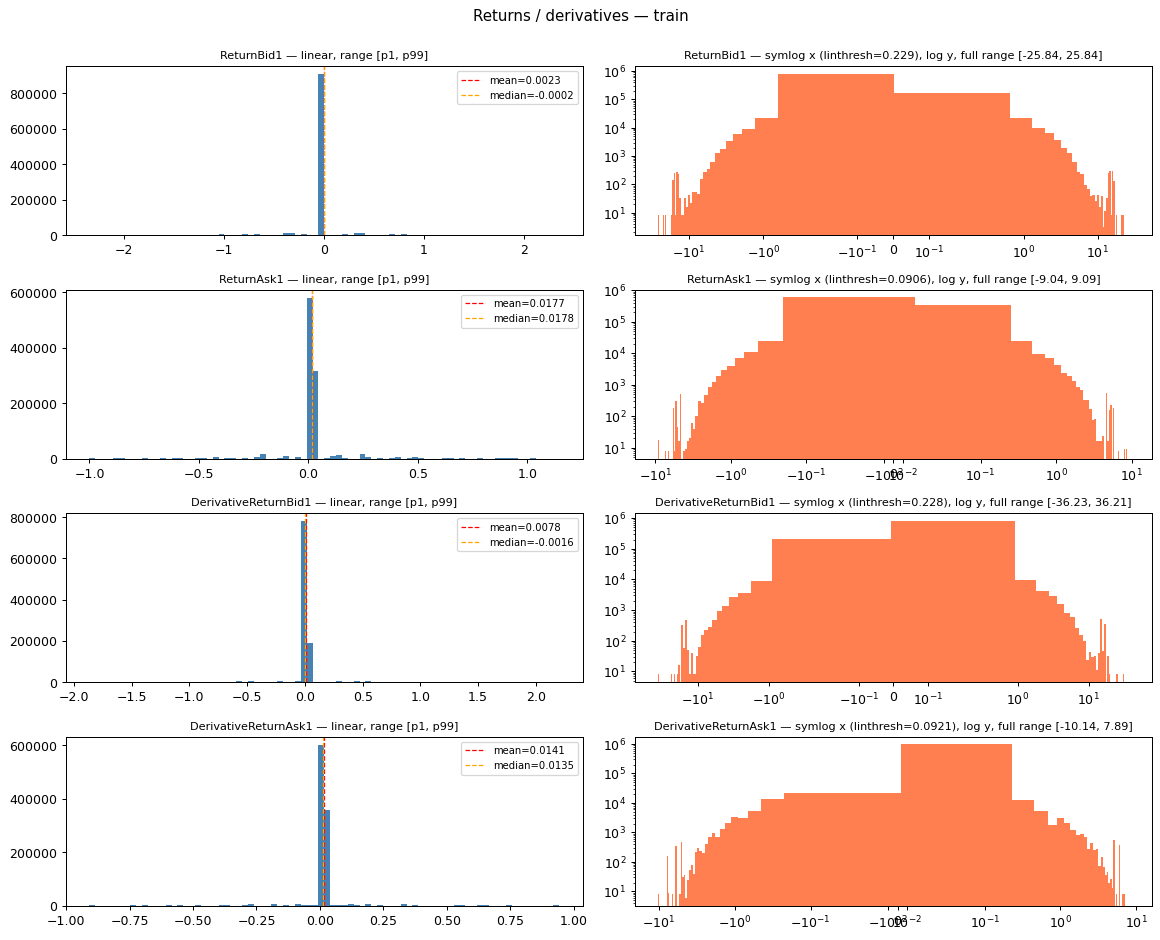

In [7]:
returns_cols = ['ReturnBid1','ReturnAsk1','DerivativeReturnBid1','DerivativeReturnAsk1']
fig, axes = plt.subplots(len(returns_cols), 2, figsize=(13, 2.6*len(returns_cols)))
fig.suptitle('Returns / derivatives — train', y=1.00, fontsize=12)
for i, col in enumerate(returns_cols):
    plot_feature_hist(train[col], axes[i,0], axes[i,1], col)
plt.tight_layout()
plt.show()

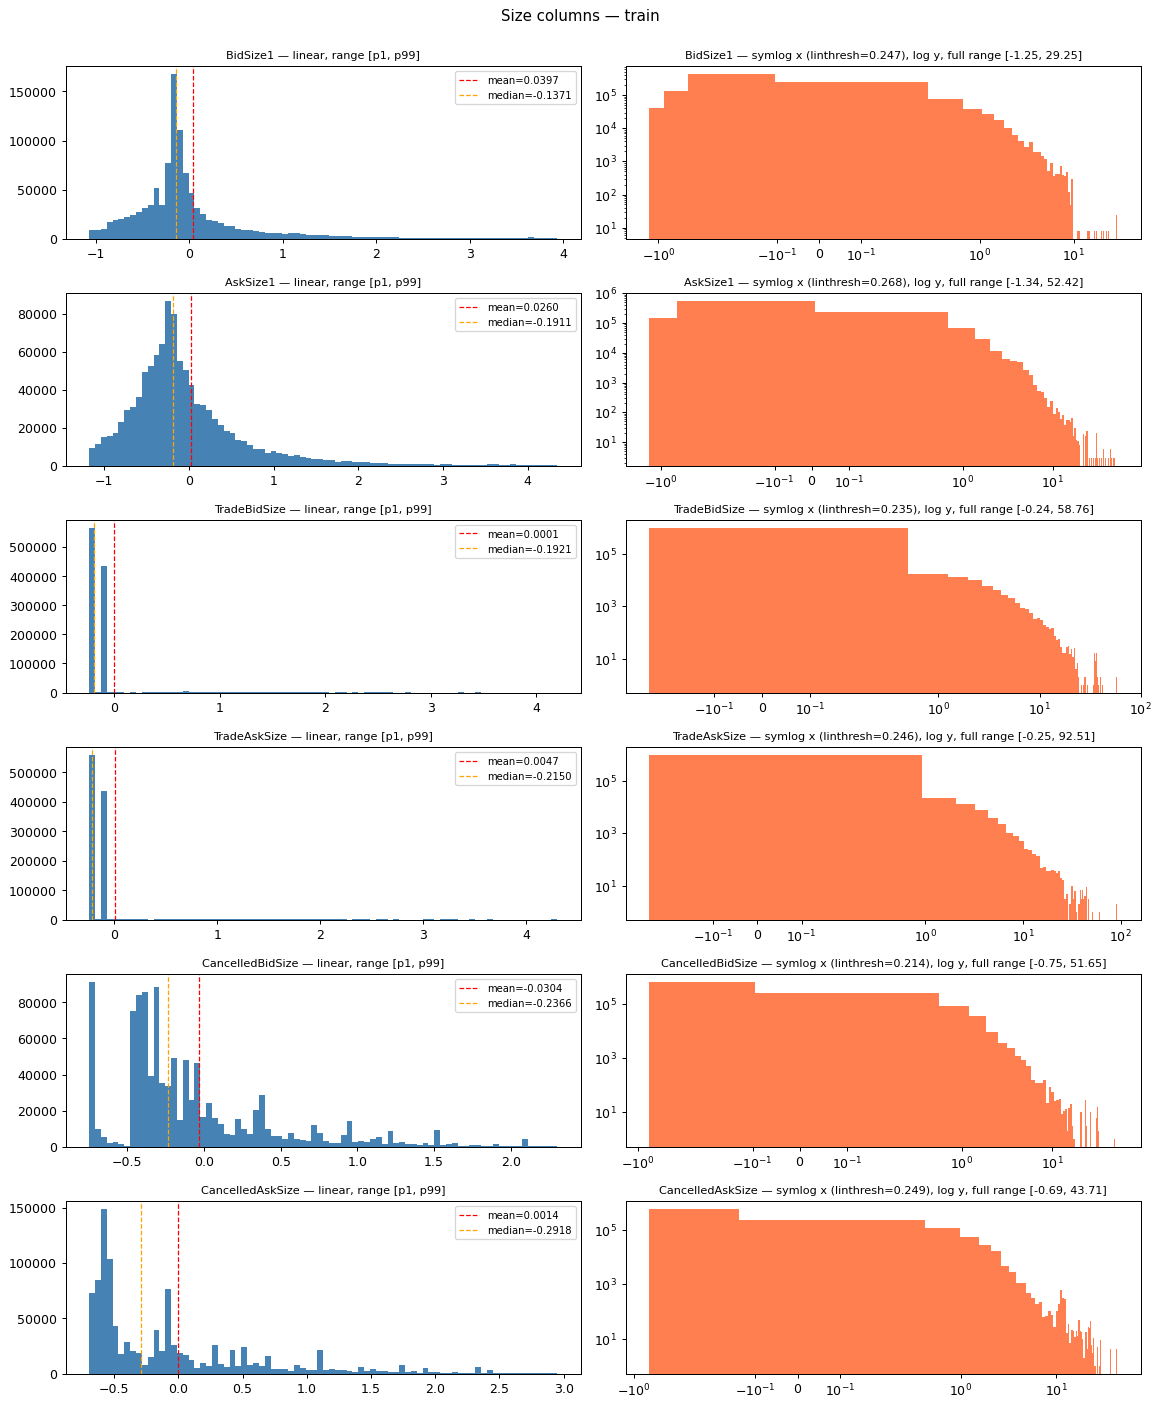

In [8]:
sizes_cols = ['BidSize1','AskSize1','TradeBidSize','TradeAskSize','CancelledBidSize','CancelledAskSize']
fig, axes = plt.subplots(len(sizes_cols), 2, figsize=(13, 2.6*len(sizes_cols)))
fig.suptitle('Size columns — train', y=1.00, fontsize=12)
for i, col in enumerate(sizes_cols):
    plot_feature_hist(train[col], axes[i,0], axes[i,1], col)
plt.tight_layout()
plt.show()

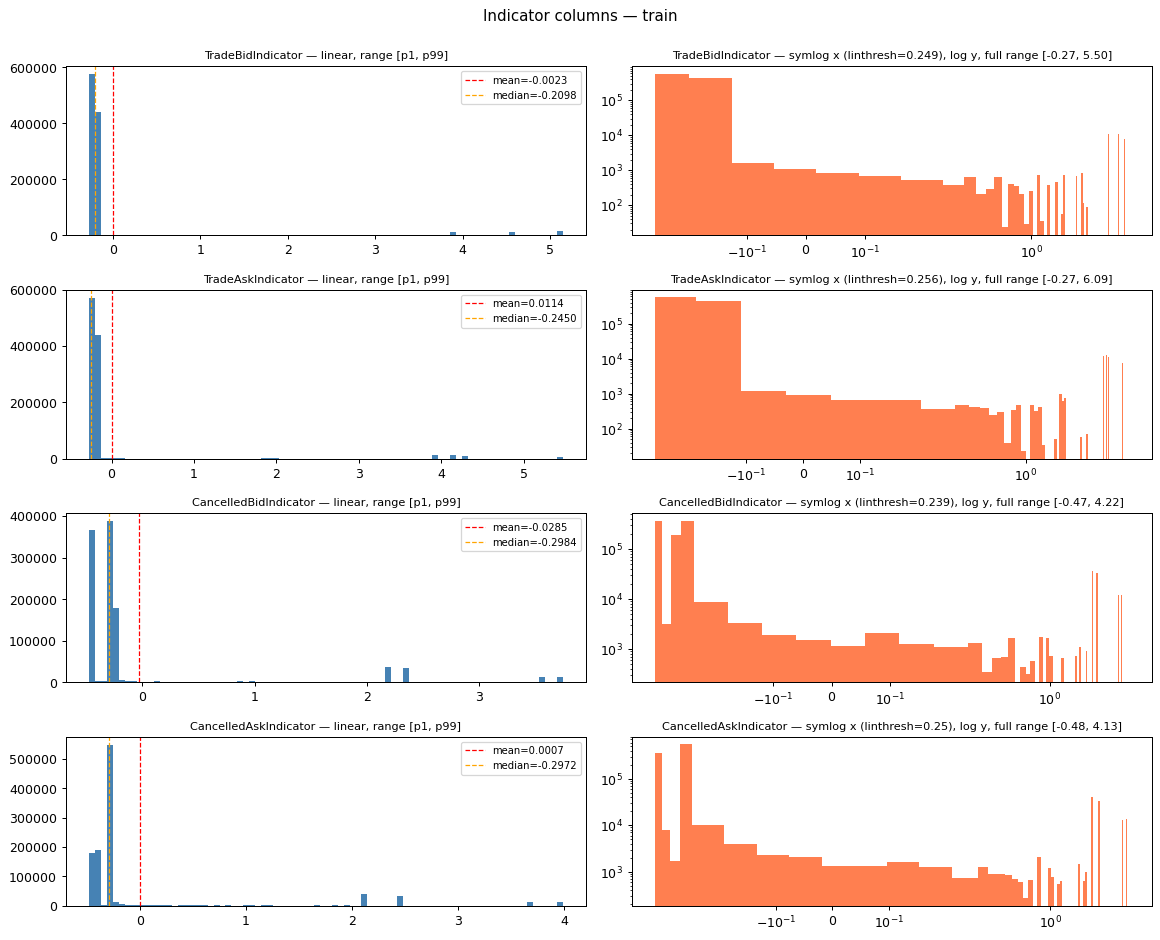

In [9]:
indicators_cols = ['TradeBidIndicator','TradeAskIndicator','CancelledBidIndicator','CancelledAskIndicator']
fig, axes = plt.subplots(len(indicators_cols), 2, figsize=(13, 2.6*len(indicators_cols)))
fig.suptitle('Indicator columns — train', y=1.00, fontsize=12)
for i, col in enumerate(indicators_cols):
    plot_feature_hist(train[col], axes[i,0], axes[i,1], col)
plt.tight_layout()
plt.show()

### Observations from Section 1

**Headline finding**: The data is heavily preprocessed in non-textbook ways, and several columns have formatting / quality issues we'll need to handle.

- **The numeric features are already preprocessed**: means clustered near 0 (but not exactly — e.g. `BidSize1` mean ≈ 0.04), stds near 1, with extreme right tails reaching +30 to +50 standard deviations. The exact transformation isn't a textbook z-score.
- **`ClusterNo` is 100% NaN** in the full train and val — a completely empty column. Drop it.
- **Format mismatches across splits**: `Date` is `'20120621.0-100'` in train/val but `'20120621-0'` in test; `OriginalSequenceNumber` is `int64` in train/val but `object` (with strings like `'16120456-000001-000'`) in test.
- **Mass spikes are a major feature of the data**: `TradeBidSize` and `TradeAskSize` each have **~20% of all rows piled at a single negative value**; `CancelledBid/AskSize` have ~7–8%. These are the rows where "nothing happened" got mapped to one specific preprocessed value. Linear histograms hide them; the symlog plots in 1.4 reveal them.
- **Only the `Derivative*` columns are symmetric around zero** (consistent with being actual time-derivatives). Sizes and indicators are right-skewed.
- **Test has small NaN counts** (1 in each return column, 36 in each size column); train and val have no NaNs in any feature column. These rows in test will need handling at prediction time.

### End of Section 1

Section 1 (univariate distributions) is now complete. The next section will compare distributions across train, val, and test more rigorously, using overlay histograms and Kolmogorov–Smirnov tests.

## 2. Train vs. Val vs. Test Distributional Comparison

Train and val are both 100% normal samples; test is a mix of normal and anomalous events. So we expect:

- **train ↔ val**: should look essentially the same. If they don't, it's a *split-related* problem (sampling bias / leakage / temporal shift), not anomalies.
- **train ↔ test**: will differ. Some of the difference is anomalies in test (the signal we want to model), and some may be unrelated drift (different symbol mix, different time window, etc.).

To separate the two, the section is structured as:

- **2.1** Side-by-side summary stats (mean / std / median per split per feature) so we can scan for drift visually.
- **2.2** Overlaid density histograms per feature — train (blue), val (green), test (orange).
- **2.3** Two-sample Kolmogorov–Smirnov tests on the full splits.
- **2.4** KS tests restricted to the **common subset** (symbols and dates appearing in all three splits) so that "AMZN appears only in test" doesn't masquerade as drift.

A practical reading of the K–S `D` statistic at this sample size:

| `D` | Interpretation |
|---|---|
| `< 0.02` | distributions essentially identical |
| `0.02 – 0.10` | small differences |
| `0.10 – 0.20` | moderate differences |
| `> 0.20` | substantial distributional drift |

(The `p`-values from KS tests on millions of samples are effectively zero for any non-trivial difference, so we read the `D` statistic, not the `p`-value.)

### 2.1 Side-by-side summary statistics

For each numeric feature, we line up `mean`, `std`, and `p50` (median) across the three splits. The differences from train (`Δ_val` and `Δ_test` for the mean) are added so drift jumps out visually. The table is sorted by `|Δ_test|` in mean, so the columns most different in test rise to the top.

In [10]:
def split_compare_table(features):
    rows = []
    for col in features:
        row = {'feature': col}
        for label, df in [('train', train), ('val', val), ('test', test)]:
            if col in df.columns:
                s = df[col].dropna()
                row[f'{label}_mean'] = s.mean()
                row[f'{label}_std']  = s.std()
                row[f'{label}_p50']  = s.median()
            else:
                row[f'{label}_mean'] = np.nan
                row[f'{label}_std']  = np.nan
                row[f'{label}_p50']  = np.nan
        row['delta_mean_val']  = row['val_mean']  - row['train_mean']
        row['delta_mean_test'] = row['test_mean'] - row['train_mean']
        rows.append(row)
    out = pd.DataFrame(rows).set_index('feature')
    return out

cmp_table = split_compare_table(numeric_features)
cmp_table_sorted = cmp_table.reindex(cmp_table['delta_mean_test'].abs().sort_values(ascending=False).index)

print('=== Per-feature mean / std / p50 across splits, sorted by |Δ_test mean| ===')
display(cmp_table_sorted[['train_mean','val_mean','test_mean','delta_mean_val','delta_mean_test',
                          'train_std','val_std','test_std',
                          'train_p50','val_p50','test_p50']])

=== Per-feature mean / std / p50 across splits, sorted by |Δ_test mean| ===


,train_mean,val_mean,test_mean,delta_mean_val,delta_mean_test,train_std,val_std,test_std,train_p50,val_p50,test_p50
feature,,,,,,,,,,,
TradeAskSize,0.0047,-0.0333,0.2907,-0.0380,0.2860,0.9836,0.8535,7.0411,-0.2150,-0.2150,-0.1146
CancelledBidSize,-0.0304,-0.0234,0.1474,0.0070,0.1778,0.8562,0.7161,2.4756,-0.2366,-0.1832,-0.2827
CancelledBidIndicator,-0.0285,0.0097,0.1063,0.0382,0.1348,0.9563,1.0149,1.1474,-0.2984,-0.2984,-0.4352
BidSize1,0.0397,-0.0456,-0.0707,-0.0853,-0.1104,0.9899,0.6638,1.1635,-0.1371,-0.1449,-0.1852
CancelledAskSize,0.0014,-0.0058,-0.0795,-0.0073,-0.0810,0.9950,0.8967,1.0242,-0.2918,-0.2905,-0.4696
CancelledAskIndicator,0.0007,-0.0039,0.0594,-0.0046,0.0587,1.0016,0.9955,1.1013,-0.2972,-0.2972,-0.4227
TradeAskIndicator,0.0114,-0.0290,-0.0398,-0.0404,-0.0512,1.0227,0.9396,0.9031,-0.2450,-0.2450,-0.1842
DerivativeReturnAsk1,0.0141,0.0142,-0.0308,0.0001,-0.0449,0.3685,0.3363,2.1174,0.0135,0.0135,0.0078
AskSize1,0.0260,-0.0642,-0.0020,-0.0902,-0.0280,1.0738,0.6554,1.2625,-0.1911,-0.1860,-0.2097


### 2.2 Overlaid density histograms (train / val / test)

For each feature we plot all three splits on the same axes, density-normalized so they're directly comparable. The plotting range is fixed to the **train** column's `[p1, p99]` so the bulk of the distribution dominates the view; tails outside that range are ignored visually but are picked up by the K–S tests in 2.3.

Color key:
- **train** — steel blue
- **val** — sea green
- **test** — coral

Visual reading: where train and val overlap tightly but test diverges, that feature is a candidate signal column for anomaly detection.

In [11]:
def plot_split_overlay(s_tr, s_va, s_te, ax, name):
    s_tr = s_tr.dropna()
    p1, p99 = s_tr.quantile([0.01, 0.99])
    rng = (p1, p99)

    ax.hist(s_tr,           bins=80, range=rng, density=True, color='steelblue', alpha=0.5, label=f'train (n={len(s_tr):,})')
    ax.hist(s_va.dropna(),  bins=80, range=rng, density=True, color='seagreen',  alpha=0.5, label=f'val (n={len(s_va.dropna()):,})')
    ax.hist(s_te.dropna(),  bins=80, range=rng, density=True, color='coral',     alpha=0.5, label=f'test (n={len(s_te.dropna()):,})')
    ax.set_title(f'{name} — density on train [p1, p99]', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')

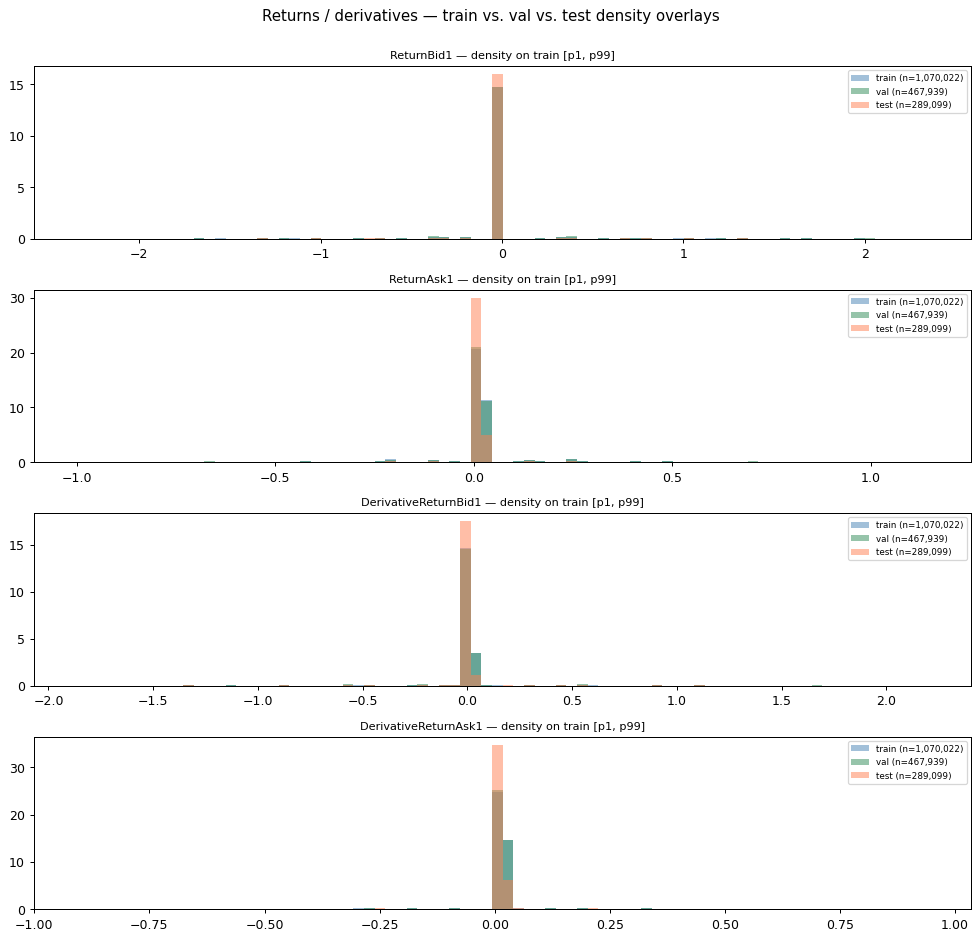

In [12]:
fig, axes = plt.subplots(len(returns_cols), 1, figsize=(11, 2.6*len(returns_cols)))
fig.suptitle('Returns / derivatives — train vs. val vs. test density overlays', y=1.00, fontsize=12)
for i, col in enumerate(returns_cols):
    plot_split_overlay(train[col], val[col], test[col], axes[i], col)
plt.tight_layout()
plt.show()

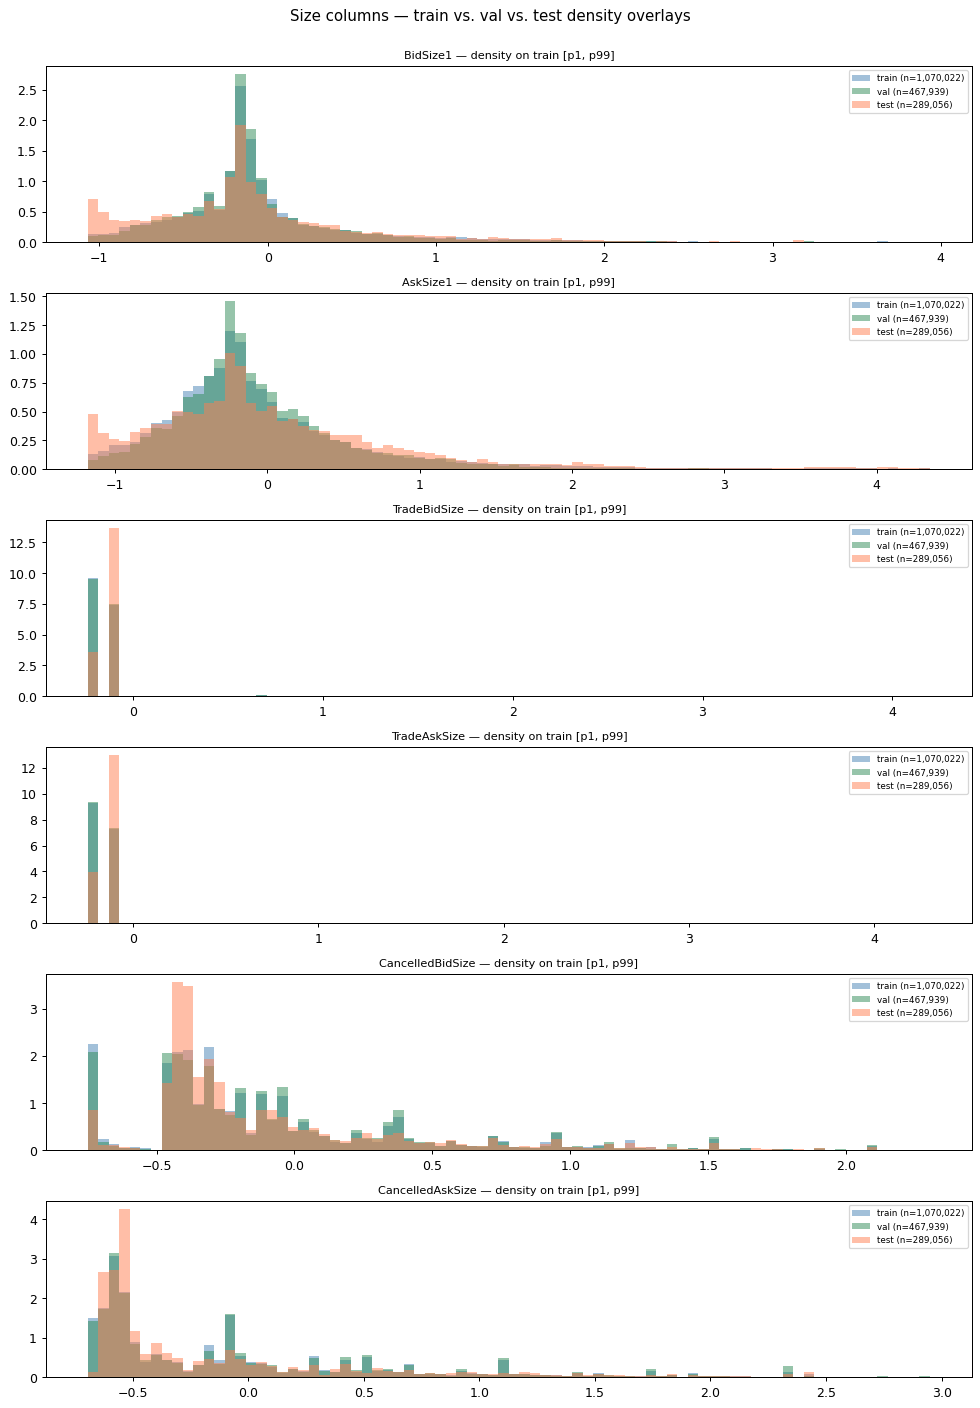

In [13]:
fig, axes = plt.subplots(len(sizes_cols), 1, figsize=(11, 2.6*len(sizes_cols)))
fig.suptitle('Size columns — train vs. val vs. test density overlays', y=1.00, fontsize=12)
for i, col in enumerate(sizes_cols):
    plot_split_overlay(train[col], val[col], test[col], axes[i], col)
plt.tight_layout()
plt.show()

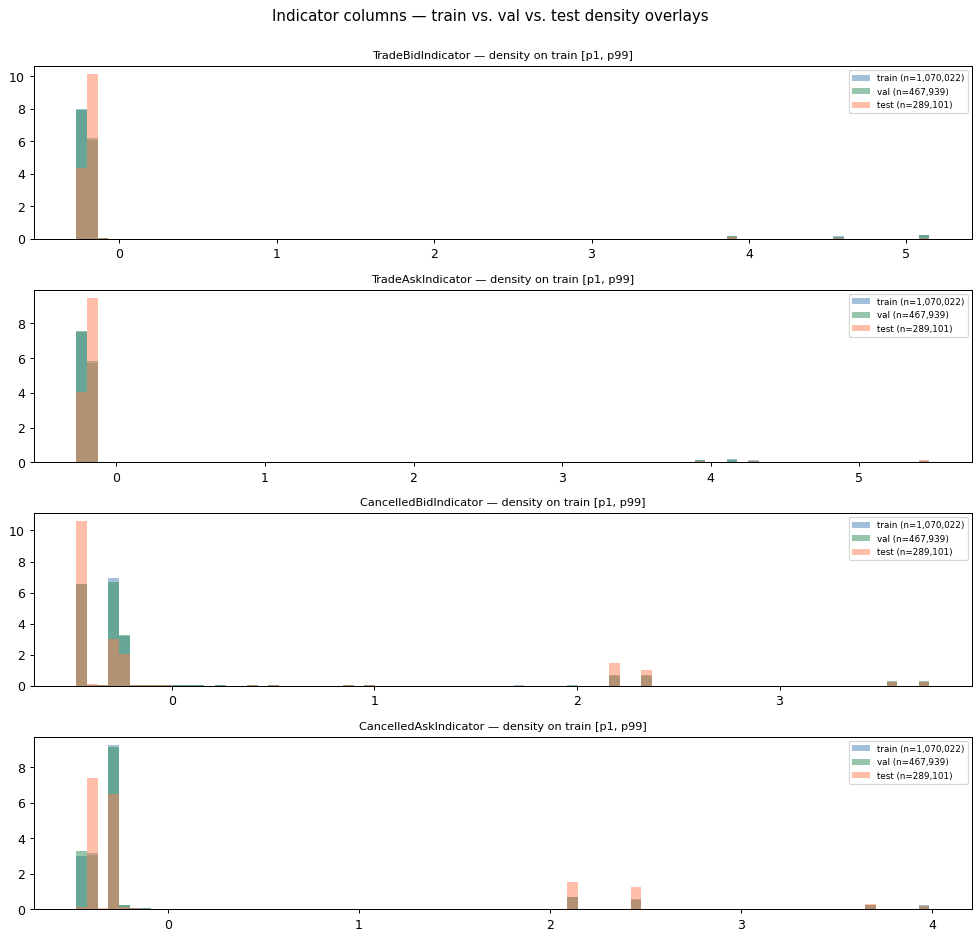

In [14]:
fig, axes = plt.subplots(len(indicators_cols), 1, figsize=(11, 2.6*len(indicators_cols)))
fig.suptitle('Indicator columns — train vs. val vs. test density overlays', y=1.00, fontsize=12)
for i, col in enumerate(indicators_cols):
    plot_split_overlay(train[col], val[col], test[col], axes[i], col)
plt.tight_layout()
plt.show()

### 2.3 Kolmogorov–Smirnov tests on the full splits

For each numeric feature we run two two-sample K–S tests:

- `train ↔ val` — should yield small `D` (both sets are 100% normal).
- `train ↔ test` — expect larger `D` due to anomalies in test (and any unrelated drift).

`D` is the maximum absolute difference between the empirical CDFs and lies in `[0, 1]`. We sort the table by `D_train_vs_test` (descending) so the most divergent columns appear first.

In [15]:
from scipy.stats import ks_2samp

def ks_table(features, df_a, df_b, df_c, label_a='train', label_b='val', label_c='test'):
    rows = []
    for col in features:
        s_a = df_a[col].dropna().to_numpy() if col in df_a.columns else np.array([])
        s_b = df_b[col].dropna().to_numpy() if col in df_b.columns else np.array([])
        s_c = df_c[col].dropna().to_numpy() if col in df_c.columns else np.array([])
        D_ab, p_ab = (ks_2samp(s_a, s_b) if len(s_a) and len(s_b) else (np.nan, np.nan))
        D_ac, p_ac = (ks_2samp(s_a, s_c) if len(s_a) and len(s_c) else (np.nan, np.nan))
        rows.append({
            'feature': col,
            f'D_{label_a}_vs_{label_b}': D_ab,
            f'p_{label_a}_vs_{label_b}': p_ab,
            f'D_{label_a}_vs_{label_c}': D_ac,
            f'p_{label_a}_vs_{label_c}': p_ac,
        })
    return pd.DataFrame(rows).set_index('feature')

ks_full = ks_table(numeric_features, train, val, test)
ks_full_sorted = ks_full.sort_values('D_train_vs_test', ascending=False)

print('=== K–S two-sample test, full splits, sorted by D_train_vs_test ===')
display(ks_full_sorted.round({'D_train_vs_val': 4, 'D_train_vs_test': 4, 'p_train_vs_val': 4, 'p_train_vs_test': 4}))

=== K–S two-sample test, full splits, sorted by D_train_vs_test ===


,D_train_vs_val,p_train_vs_val,D_train_vs_test,p_train_vs_test
feature,,,,
TradeBidSize,0.0134,0.0000,0.6463,0.0000
DerivativeReturnAsk1,0.0125,0.0000,0.4580,0.0000
TradeBidIndicator,0.0135,0.0000,0.4512,0.0000
ReturnBid1,0.0152,0.0000,0.4490,0.0000
TradeAskSize,0.0140,0.0000,0.4447,0.0000
ReturnAsk1,0.0159,0.0000,0.4414,0.0000
CancelledBidIndicator,0.0136,0.0000,0.3748,0.0000
TradeAskIndicator,0.0195,0.0000,0.3283,0.0000
DerivativeReturnBid1,0.0114,0.0000,0.2920,0.0000


### 2.4 KS tests on the common subset

A potential confounder for 2.3 is that the three splits don't necessarily contain the same symbols on the same dates. If, say, `AMZN` appears only in test, that alone will skew test's distribution and look like drift. To control for this we restrict every split to:

- the **intersection of `ExternalSymbol`** values across all three splits
- the **intersection of date prefixes** (the first 8 chars `YYYYMMDD` of `Date`, which is consistent across the differently-formatted Date strings in each split)

…and re-run the K–S tests on that common subset. Comparing 2.3 vs. 2.4 tells us whether the apparent drift in 2.3 is driven by the symbol/date mix or is genuinely intrinsic to the test sample (i.e., real anomalies / true distributional change).

In [16]:
def date_prefix(s):
    return s.astype(str).str[:8]

train_syms = set(train['ExternalSymbol'].unique())
val_syms   = set(val['ExternalSymbol'].unique())
test_syms  = set(test['ExternalSymbol'].unique())
common_syms = train_syms & val_syms & test_syms

train_dates = set(date_prefix(train['Date']).unique())
val_dates   = set(date_prefix(val['Date']).unique())
test_dates  = set(date_prefix(test['Date']).unique())
common_dates = train_dates & val_dates & test_dates

print(f'Symbols     — train: {sorted(train_syms)}')
print(f'              val:   {sorted(val_syms)}')
print(f'              test:  {sorted(test_syms)}')
print(f'              common: {sorted(common_syms)}')
print()
print(f'Date prefix — train: {sorted(train_dates)}')
print(f'              val:   {sorted(val_dates)}')
print(f'              test:  {sorted(test_dates)}')
print(f'              common: {sorted(common_dates)}')

train_c = train[train['ExternalSymbol'].isin(common_syms) & date_prefix(train['Date']).isin(common_dates)]
val_c   = val  [val  ['ExternalSymbol'].isin(common_syms) & date_prefix(val  ['Date']).isin(common_dates)]
test_c  = test [test ['ExternalSymbol'].isin(common_syms) & date_prefix(test ['Date']).isin(common_dates)]

print()
print(f'After common-subset filter:')
print(f'  train_c: {train_c.shape}  (was {train.shape})')
print(f'  val_c:   {val_c.shape}  (was {val.shape})')
print(f'  test_c:  {test_c.shape}  (was {test.shape})')

Symbols     — train: ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']
              val:   ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']
              test:  ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']
              common: ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']

Date prefix — train: ['20120621', '20130621', '20140621', '20150621', '20160621', '20170621', '20180621', '20190621']
              val:   ['20120621', '20130621', '20140621', '20150621', '20160621', '20170621', '20180621', '20190621', '20200621', '20210621', '20220621', '20230621', '20240621']
              test:  ['20120621']
              common: ['20120621']



After common-subset filter:
  train_c: (678918, 23)  (was (1070022, 23))
  val_c:   (273445, 23)  (was (467939, 23))
  test_c:  (289101, 21)  (was (289101, 21))


In [17]:
ks_common = ks_table(numeric_features, train_c, val_c, test_c)

# Side-by-side comparison: full vs common D-statistics, sorted by full train-vs-test
combined = pd.DataFrame({
    'D_train_vs_val_FULL':    ks_full['D_train_vs_val'],
    'D_train_vs_val_COMMON':  ks_common['D_train_vs_val'],
    'D_train_vs_test_FULL':   ks_full['D_train_vs_test'],
    'D_train_vs_test_COMMON': ks_common['D_train_vs_test'],
})
combined['delta_test_FULL_minus_COMMON'] = combined['D_train_vs_test_FULL'] - combined['D_train_vs_test_COMMON']
combined = combined.sort_values('D_train_vs_test_FULL', ascending=False).round(4)

print('=== K–S D-statistics: full splits vs. common-subset (intersection of symbols and dates) ===')
print('    A positive delta_test_FULL_minus_COMMON means the full-split drift was inflated by symbol/date mix differences;')
print('    a delta near zero means the drift is intrinsic (anomalies / true distribution shift).')
display(combined)

=== K–S D-statistics: full splits vs. common-subset (intersection of symbols and dates) ===
    A positive delta_test_FULL_minus_COMMON means the full-split drift was inflated by symbol/date mix differences;
    a delta near zero means the drift is intrinsic (anomalies / true distribution shift).


,D_train_vs_val_FULL,D_train_vs_val_COMMON,D_train_vs_test_FULL,D_train_vs_test_COMMON,delta_test_FULL_minus_COMMON
feature,,,,,
TradeBidSize,0.0134,0.0630,0.6463,0.6562,-0.0099
DerivativeReturnAsk1,0.0125,0.0593,0.4580,0.3568,0.1011
TradeBidIndicator,0.0135,0.0638,0.4512,0.3409,0.1103
ReturnBid1,0.0152,0.0565,0.4490,0.3564,0.0925
TradeAskSize,0.0140,0.0553,0.4447,0.3419,0.1028
ReturnAsk1,0.0159,0.0551,0.4414,0.3502,0.0913
CancelledBidIndicator,0.0136,0.0498,0.3748,0.2767,0.0981
TradeAskIndicator,0.0195,0.0581,0.3283,0.3374,-0.0091
DerivativeReturnBid1,0.0114,0.0459,0.2920,0.3067,-0.0147


### Observations from Section 2

**Headline finding**: Train and val are interchangeable; test is structurally very different from train along multiple confounded axes (date, symbol mix, distribution).

- **Train and val are interchangeable** — KS `D` between them is `0.01–0.04` for every column. The split is healthy; no leakage.
- **The biggest, most unexpected finding**: test contains data from **only one day** (2012-06-21), while train spans 8 dates (June 21 of 2012-2019) and val spans 13 dates (2012-2024). The intersection across all three is one day. Within train, **63% of all rows are already on 2012-06-21**, which makes restricting train to that day a near-free lunch.
- **All 5 symbols appear in all 3 splits** — symbol overlap is fine; it's the date set that's confounding.
- **Train↔test drift is feature-specific**: `TradeBidSize` has `D = 0.65` (largest); other sizes and returns have `D = 0.13–0.46`. After restricting to the common date, some features' drift drops by ~0.10 (it was a date-mix artifact); `TradeBidSize`'s drift barely budges (so it's an intrinsic test signal — likely real anomaly content).
- **Modelling implication**: when training, restricting to 2012-06-21 (679K rows) gives a training distribution closer to what test actually represents. Section 4 will dig further into the temporal axis.

### End of Section 2

Section 2 is complete. The next section will look at how feature distributions vary **per stock symbol** — a different cut of the same data that helps decide whether to model globally or per-symbol.

## 3. Per-Symbol Heterogeneity

The five symbols (AAPL, AMZN, GOOG, INTC, MSFT) trade at very different price points (AAPL/GOOG hundreds of dollars, INTC tens of dollars), with different tick sizes, depths, and event rates. A pattern that is *normal* for INTC may be unusual for AAPL. Before deciding whether to model globally with `ExternalSymbol` as a feature, or per-symbol with five separate models, we want to know **how different the per-symbol distributions actually are**.

Sub-steps:

- **3.1** Per-symbol event counts in each split — sanity check that all symbols are present in train, val, and test.
- **3.2** Per-symbol mean / std for every numeric feature on **train**, with a spread column so the most heterogeneous features rise to the top.
- **3.3** Per-symbol density-overlay histograms (one colored line per symbol) for returns, sizes, and indicators.

A caveat: train spans 8 dates (June 21st of 2012–2019), and per-symbol stats on the full train mix together date and symbol effects. Section 4 disentangles dates explicitly; here we treat the union of (symbol × date) within train as "what normal looks like for that symbol overall."

### 3.1 Per-symbol event counts across splits

In [18]:
cnt_tbl = pd.DataFrame({
    'train': train['ExternalSymbol'].value_counts(),
    'val':   val  ['ExternalSymbol'].value_counts(),
    'test':  test ['ExternalSymbol'].value_counts(),
}).fillna(0).astype(int).sort_index()

for col in ['train','val','test']:
    cnt_tbl[f'{col}_pct'] = (cnt_tbl[col] / cnt_tbl[col].sum() * 100).round(2)

print('=== Event counts and within-split share by ExternalSymbol ===')
display(cnt_tbl[['train','train_pct','val','val_pct','test','test_pct']])

=== Event counts and within-split share by ExternalSymbol ===


,train,train_pct,val,val_pct,test,test_pct
ExternalSymbol,,,,,,
AAPL,190575,17.8100,83980,17.9500,35176,12.1700
AMZN,212912,19.9000,90760,19.4000,29807,10.3100
GOOG,215865,20.1700,93212,19.9200,23521,8.1400
INTC,226109,21.1300,94578,20.2100,103496,35.8000
MSFT,224561,20.9900,105409,22.5300,97101,33.5900


### 3.2 Per-symbol mean / std on train, by feature

For every numeric feature, we compute the mean and the standard deviation **per symbol** (on train). Two tables are produced:

- A `mean` table (rows = features, columns = the 5 symbols) plus a `spread` column = `max − min` of the per-symbol means. Sorting by spread surfaces the features whose **central tendency** differs most across symbols.
- A `std` table with a `ratio` column = `max / min` of the per-symbol stds. Sorting by ratio surfaces the features whose **scale** differs most across symbols.

A feature with a large spread or large ratio is poorly modelled by one global "normal" distribution — it would benefit from per-symbol re-standardization or per-symbol modelling.

In [19]:
mean_by_sym = train.groupby('ExternalSymbol')[numeric_features].mean().T
std_by_sym  = train.groupby('ExternalSymbol')[numeric_features].std().T

mean_by_sym['spread (max-min)'] = mean_by_sym.max(axis=1) - mean_by_sym.min(axis=1)
std_by_sym ['ratio (max/min)']  = std_by_sym.max(axis=1)  / std_by_sym.min(axis=1)

mean_by_sym_sorted = mean_by_sym.sort_values('spread (max-min)', ascending=False)
std_by_sym_sorted  = std_by_sym .sort_values('ratio (max/min)',  ascending=False)

print('=== Per-symbol MEAN by feature (train), sorted by between-symbol spread ===')
display(mean_by_sym_sorted.round(4))

print('\n=== Per-symbol STD by feature (train), sorted by between-symbol ratio ===')
display(std_by_sym_sorted.round(4))

=== Per-symbol MEAN by feature (train), sorted by between-symbol spread ===


ExternalSymbol,AAPL,AMZN,GOOG,INTC,MSFT,spread (max-min)
BidSize1,-0.0624,0.0109,0.1020,0.0869,0.0461,0.1644
CancelledBidSize,-0.0125,0.0002,-0.1189,-0.0015,-0.0186,0.1190
CancelledAskSize,-0.0307,0.0390,-0.0505,0.0250,0.0193,0.0895
CancelledBidIndicator,-0.0086,-0.0360,-0.0668,-0.0258,-0.0040,0.0628
TradeBidSize,-0.0183,-0.0044,0.0324,-0.0082,-0.0026,0.0507
TradeBidIndicator,-0.0147,-0.0143,0.0272,-0.0073,-0.0038,0.0418
DerivativeReturnBid1,0.0046,-0.0034,0.0383,-0.0006,0.0005,0.0417
CancelledAskIndicator,-0.0106,-0.0156,0.0197,0.0099,-0.0017,0.0354
TradeAskSize,0.0182,-0.0087,0.0147,0.0059,-0.0049,0.0269
TradeAskIndicator,0.0133,0.0078,0.0279,0.0035,0.0054,0.0244



=== Per-symbol STD by feature (train), sorted by between-symbol ratio ===


ExternalSymbol,AAPL,AMZN,GOOG,INTC,MSFT,ratio (max/min)
BidSize1,0.3789,1.0705,1.1936,1.0451,0.9879,3.1499
CancelledBidSize,0.8661,1.0755,0.9100,0.7388,0.6362,1.6904
CancelledAskSize,0.9259,1.2097,0.7827,1.0089,0.9915,1.5456
ReturnAsk1,0.3301,0.3950,0.4491,0.3023,0.3159,1.4853
ReturnBid1,0.9052,1.0210,0.7134,0.9514,0.9619,1.4312
TradeAskSize,1.0973,0.9495,0.9945,1.0834,0.7745,1.4167
TradeBidSize,0.9364,1.0320,1.0669,0.7648,0.8684,1.3950
DerivativeReturnBid1,0.8743,0.9953,0.7153,0.9632,0.9747,1.3915
DerivativeReturnAsk1,0.3532,0.3654,0.4430,0.3349,0.3361,1.3227
AskSize1,1.2035,1.2345,0.9353,0.9660,1.0195,1.3198


### 3.3 Per-symbol density-overlay histograms (train)

For each numeric feature we plot one density histogram **per symbol** on the same axes, using `histtype='step'` so the five outlines stay readable. The plotting range is fixed to the `[p1, p99]` of the **combined train** distribution for that feature, so all five symbols share the same x-axis and are visually comparable.

Reading the plots: where the five lines lie on top of each other, the feature is *symbol-invariant* and a global model is fine. Where they separate cleanly, the feature carries symbol-specific structure that a global model would have to either learn (via the symbol feature) or normalize away (via per-symbol standardization).

In [20]:
SYMBOL_COLORS = {
    'AAPL': 'tab:red',
    'AMZN': 'tab:orange',
    'GOOG': 'tab:green',
    'INTC': 'tab:blue',
    'MSFT': 'tab:purple',
}

def plot_per_symbol_overlay(df, col, ax):
    s_all = df[col].dropna()
    p1, p99 = s_all.quantile([0.01, 0.99])
    rng = (p1, p99)

    for sym in sorted(df['ExternalSymbol'].unique()):
        s = df.loc[df['ExternalSymbol'] == sym, col].dropna()
        if len(s) == 0:
            continue
        ax.hist(s, bins=80, range=rng, density=True, histtype='step',
                color=SYMBOL_COLORS.get(sym, 'gray'), linewidth=1.5,
                label=f'{sym} (n={len(s):,})')
    ax.set_title(f'{col} — density on combined train [p1, p99]', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')

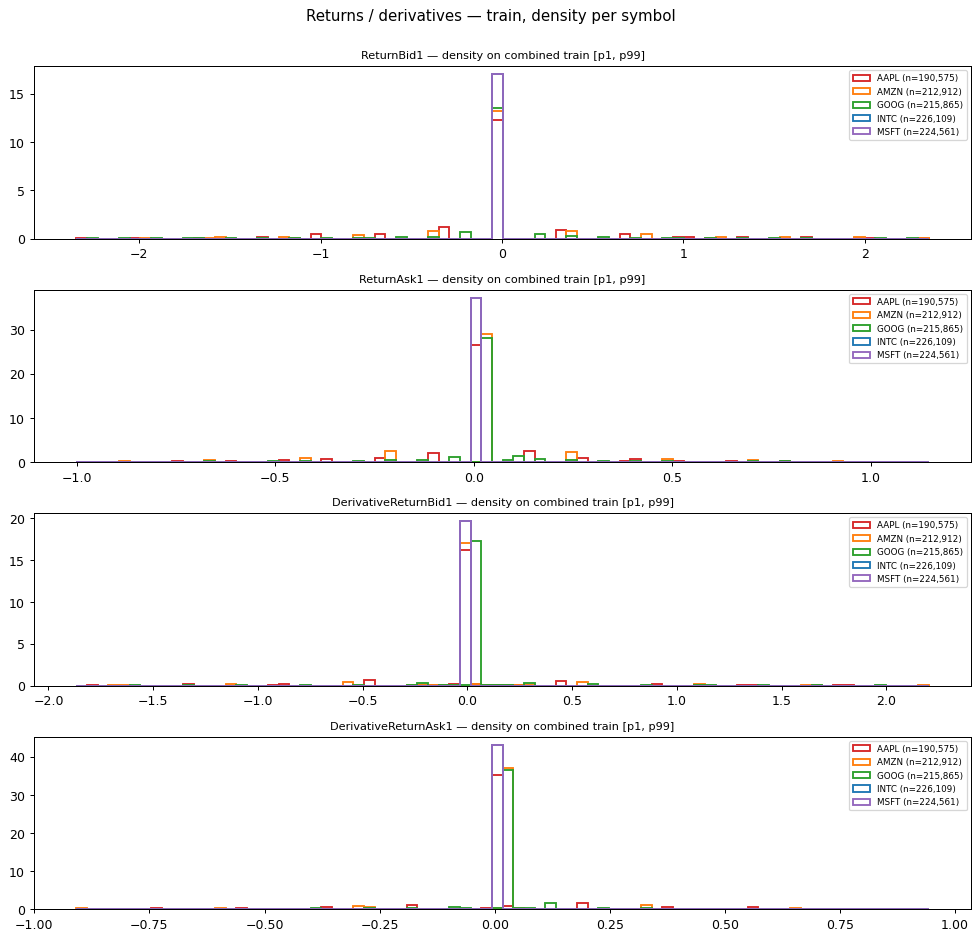

In [21]:
fig, axes = plt.subplots(len(returns_cols), 1, figsize=(11, 2.6*len(returns_cols)))
fig.suptitle('Returns / derivatives — train, density per symbol', y=1.00, fontsize=12)
for i, col in enumerate(returns_cols):
    plot_per_symbol_overlay(train, col, axes[i])
plt.tight_layout()
plt.show()

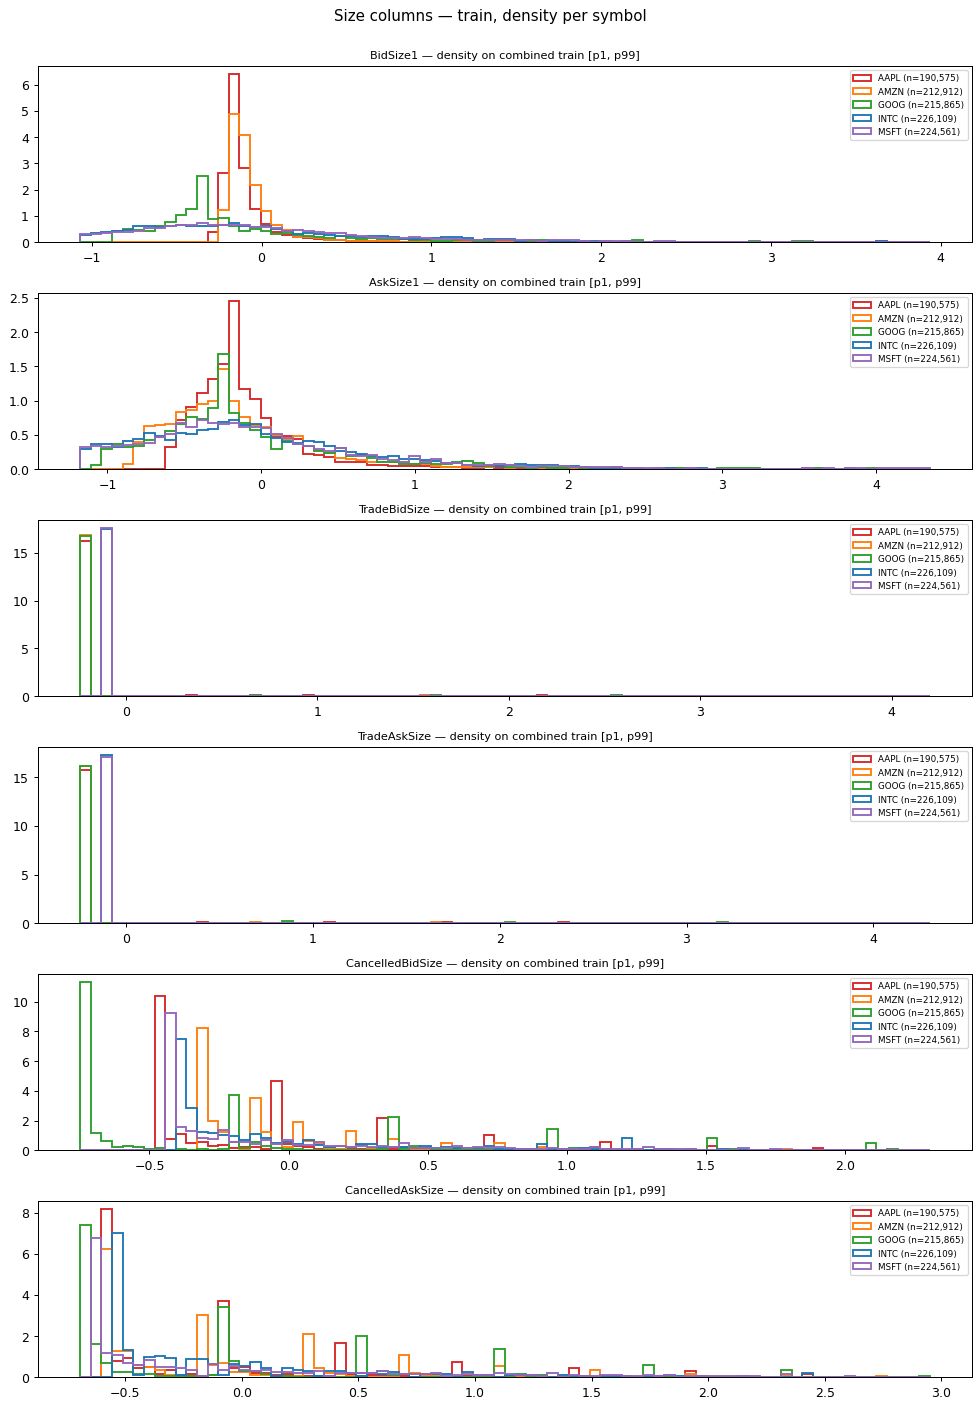

In [22]:
fig, axes = plt.subplots(len(sizes_cols), 1, figsize=(11, 2.6*len(sizes_cols)))
fig.suptitle('Size columns — train, density per symbol', y=1.00, fontsize=12)
for i, col in enumerate(sizes_cols):
    plot_per_symbol_overlay(train, col, axes[i])
plt.tight_layout()
plt.show()

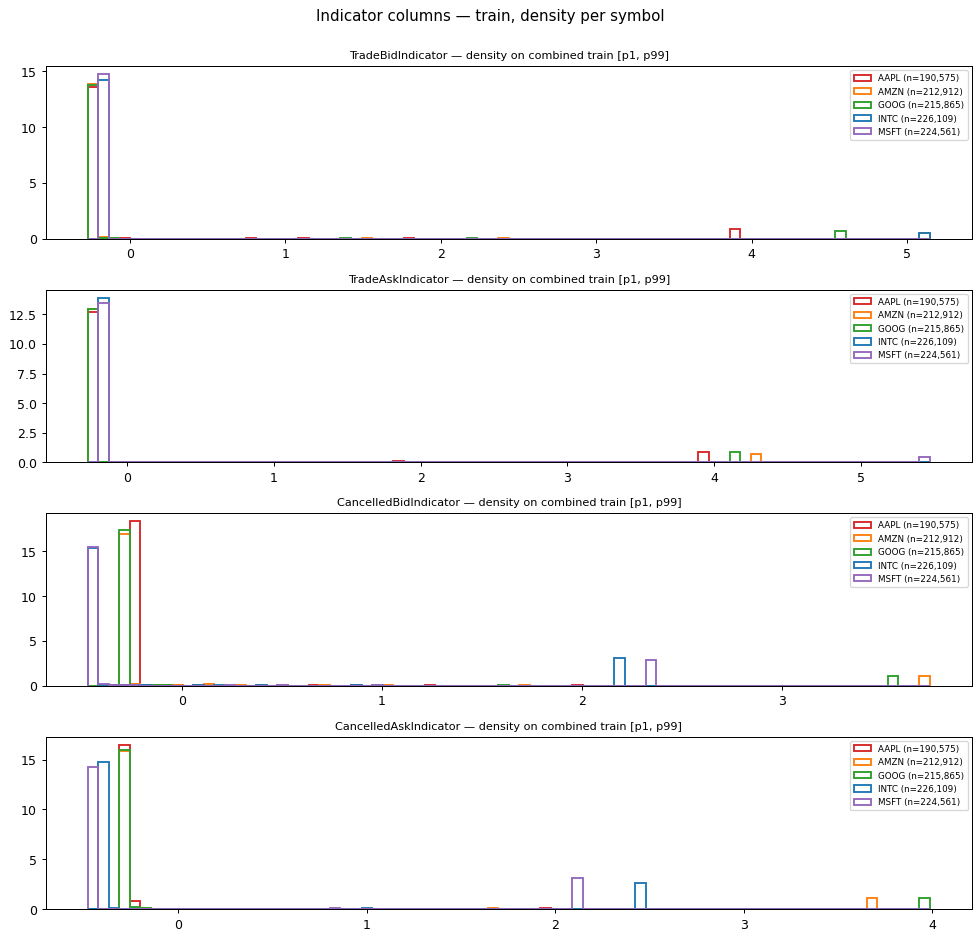

In [23]:
fig, axes = plt.subplots(len(indicators_cols), 1, figsize=(11, 2.6*len(indicators_cols)))
fig.suptitle('Indicator columns — train, density per symbol', y=1.00, fontsize=12)
for i, col in enumerate(indicators_cols):
    plot_per_symbol_overlay(train, col, axes[i])
plt.tight_layout()
plt.show()

### Observations from Section 3

**Headline finding**: Symbol mix differs sharply between train and test, but features are mostly symbol-invariant — except `BidSize1`.

- **Test has a heavily skewed symbol mix relative to train/val.** Train and val are roughly balanced (each symbol 17–22% of rows). Test is dominated by **INTC (35.8%) and MSFT (33.6%) — together 70% of test**. AAPL/AMZN/GOOG together account for only 30%. This is yet another distributional shift between train and test, on top of the date mismatch from Section 2.4.
- **`BidSize1` is the standout heterogeneous feature.** Both in central tendency (mean spread = 0.16: AAPL = -0.06, GOOG = +0.10) and especially in scale (std ratio = **3.15**: AAPL std = 0.38, GOOG std = 1.19). AAPL's bid-size distribution is much tighter than the others.
- **Most other features are surprisingly symbol-invariant.** All four indicator columns have std ratios in `[1.04, 1.12]` — nearly identical scale across symbols. Return columns have mean spreads under `0.02`. Whatever preprocessing was done, it normalized symbol scale almost everywhere — `BidSize1` is the conspicuous exception.
- **Modelling implication**: A global model with `ExternalSymbol` as a categorical feature is probably fine for most columns. `BidSize1` is the main candidate for per-symbol re-standardisation. Combined with the test-side symbol skew above, expect INTC and MSFT to dominate the test-time anomaly score distribution simply by row count.

### End of Section 3

Per-symbol heterogeneity is now characterized. The `mean spread` and `std ratio` tables in 3.2, together with the visual overlays in 3.3, provide the inputs for the modelling decision: model globally with `ExternalSymbol` as a feature, or fit five separate per-symbol models.

The next section (Section 4) looks at the data along the **time axis** — date coverage, intraday patterns, and inter-event gap distributions.

## 4. Temporal Coverage and Event-Rate Patterns

The data is a high-frequency limit-order-book feed, so the time axis is itself a feature. Three sub-questions here:

- **4.1** How are events distributed across dates and hours-of-day?
- **4.2** What is the *intraday* event rate, and does its shape match between train and test on the common date (2012-06-21)?
- **4.3** What does the inter-event gap (Δt) distribution look like, both globally and per symbol?

Why this matters for anomaly detection:

- **Quote stuffing** is *defined* as bursts of events with abnormally short Δt and no commensurate trades — so understanding the normal Δt distribution is a direct prerequisite for detecting it.
- Intraday seasonality (open/close volatility, midday lull) means a "high event rate" at noon is more anomalous than the same rate at 3:55 PM. Models should be aware of this baseline.
- Date coverage is uneven (Section 2.4 finding); we want to understand within-day structure since cross-date averaging is partially confounded.

### 4.1 Date and hour-of-day coverage

We add two derived columns to each split:
- `date_prefix`: the `YYYYMMDD` part of `Date` (8 leading characters), normalized across the differently-formatted Date strings.
- `hour`: the hour-of-day, derived from the `HHMMSS` `Time` column.

Then we tabulate event counts in each (split × date) and (split × hour) cell. Note: `TimeInMilliSecs` is milliseconds since midnight (verified by reconstruction: 9:30:00 ≈ 34,200,000 ms), so events at the U.S. equity open should cluster near minute 570 in the intraday plots that follow.

In [24]:
def add_time_features(df):
    df['date_prefix'] = df['Date'].astype(str).str[:8]
    df['hour'] = (df['Time'].astype(int) // 10000).astype(int)

for df in (train, val, test):
    add_time_features(df)

date_counts = pd.DataFrame({
    'train': train['date_prefix'].value_counts(),
    'val':   val  ['date_prefix'].value_counts(),
    'test':  test ['date_prefix'].value_counts(),
}).fillna(0).astype(int).sort_index()

print('=== Event counts per date_prefix ===')
display(date_counts)

hour_counts = pd.DataFrame({
    'train': train['hour'].value_counts(),
    'val':   val  ['hour'].value_counts(),
    'test':  test ['hour'].value_counts(),
}).fillna(0).astype(int).sort_index()

print('\n=== Event counts per hour-of-day (HH part of Time) ===')
display(hour_counts)

=== Event counts per date_prefix ===


,train,val,test
date_prefix,,,
20120621,678918,273445,289101
20130621,114124,36729,0
20140621,50599,36729,0
20150621,50599,15734,0
20160621,50599,15734,0
20170621,50599,15734,0
20180621,50599,15734,0
20190621,23985,15734,0
20200621,0,15734,0



=== Event counts per hour-of-day (HH part of Time) ===


,train,val,test
hour,,,
9,79191,24183,79591
10,176334,51838,49357
11,183777,40624,36140
12,88060,132872,23832
13,135293,69239,16931
14,139269,62012,13881
15,244550,87101,59141
16,23548,70,10228


### 4.2 Intraday event rate — train (2012-06-21) vs test

Because most of train (63%) is on 2012-06-21 — the only date in test — we compare events-per-minute on that single date for both. Same x-axis (minutes since midnight) so peaks line up. If the *shape* matches, train's intraday seasonality is a good model for test's; if it doesn't, test has structural patterns train doesn't.

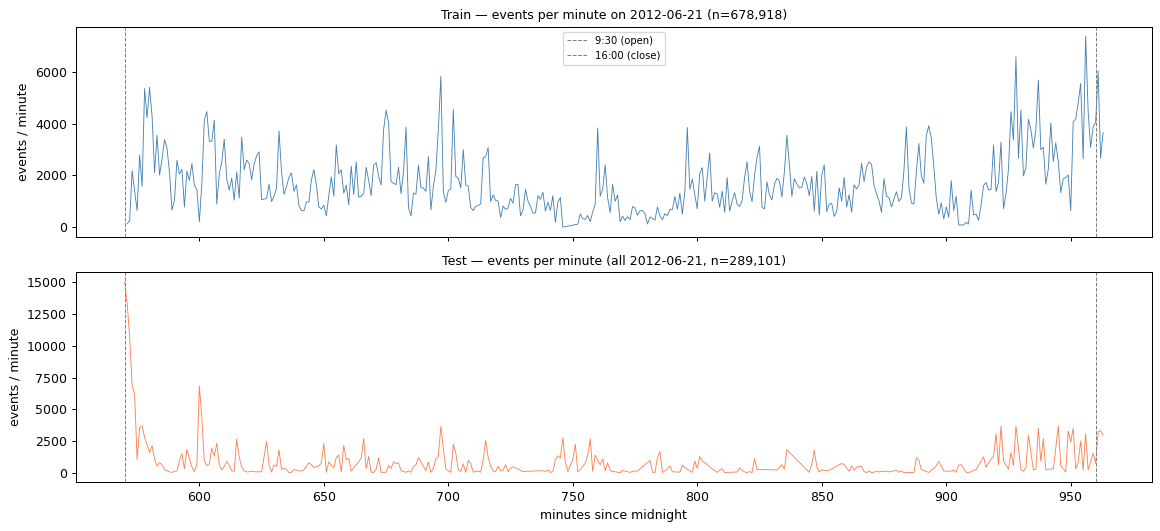

In [25]:
train_d = train[train['date_prefix'] == '20120621']
test_d  = test[test['date_prefix']  == '20120621']

def per_minute_counts(df):
    minute = (df['TimeInMilliSecs'] // 60_000).astype(int)
    return minute.value_counts().sort_index()

train_pm = per_minute_counts(train_d)
test_pm  = per_minute_counts(test_d)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(train_pm.index, train_pm.values, color='steelblue', linewidth=0.7)
axes[0].set_title(f'Train — events per minute on 2012-06-21 (n={len(train_d):,})', fontsize=10)
axes[0].set_ylabel('events / minute')
axes[0].axvline(570, color='gray', linestyle='--', linewidth=0.8, label='9:30 (open)')
axes[0].axvline(960, color='gray', linestyle='--', linewidth=0.8, label='16:00 (close)')
axes[0].legend(fontsize=8)

axes[1].plot(test_pm.index, test_pm.values, color='coral', linewidth=0.7)
axes[1].set_title(f'Test — events per minute (all 2012-06-21, n={len(test_d):,})', fontsize=10)
axes[1].set_ylabel('events / minute')
axes[1].set_xlabel('minutes since midnight')
axes[1].axvline(570, color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(960, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

### 4.3 Inter-event time gaps (Δt)

For every consecutive pair of events within the same `(ExternalSymbol, date_prefix)` group, we compute Δt = `TimeInMilliSecs[t] − TimeInMilliSecs[t−1]`. Quote-stuffing bursts would manifest as an inflated *lower tail* (sub-millisecond Δt with no trades). We compute Δt on **train (2012-06-21)** so we can compare directly to test in Section 6.

Two views:
- A symlog-x histogram on the full Δt range.
- Per-symbol density of `log10(Δt)` so we can see how arrival rates differ across stocks.

=== Δt (ms) percentile summary by symbol — train, 2012-06-21 ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ExternalSymbol,,,,,,,,,,,,
AAPL,"127,049.0000",182.5200,"9,045.5800",0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,600.0000,"2,273.0400","2,153,079.0000"
AMZN,"53,227.0000",440.3900,"9,718.9900",0.0000,0.0000,0.0000,0.0000,0.0000,4.0000,"1,358.7000","5,068.0600","1,207,741.0000"
GOOG,"47,969.0000",487.8400,"13,366.7300",0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,"1,878.6000","5,776.8800","2,421,224.0000"
INTC,"226,108.0000",103.1300,"6,258.6200",0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,390.0000,"1,293.9300","1,735,133.0000"
MSFT,"224,560.0000",104.1500,"6,909.9600",0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,305.0000,"1,368.0000","1,936,436.0000"


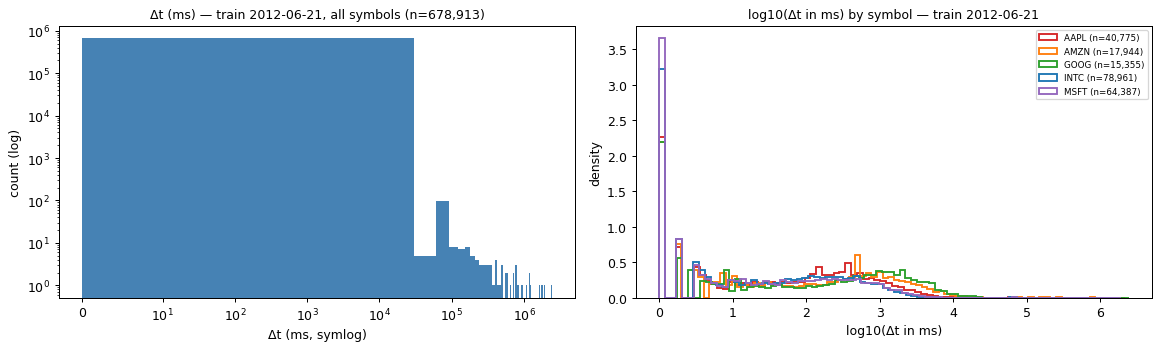

In [26]:
train_d_sorted = (train_d
                  .sort_values(['ExternalSymbol', 'TimeInMilliSecs'])
                  .reset_index(drop=True)
                  .copy())
train_d_sorted['dt'] = train_d_sorted.groupby('ExternalSymbol')['TimeInMilliSecs'].diff()
train_dt = train_d_sorted['dt'].dropna()
train_dt_pos = train_dt[train_dt > 0]

print('=== Δt (ms) percentile summary by symbol — train, 2012-06-21 ===')
display(train_d_sorted.groupby('ExternalSymbol')['dt'].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train_dt, bins=80, color='steelblue', edgecolor='none')
axes[0].set_xscale('symlog', linthresh=10)
axes[0].set_yscale('log')
axes[0].set_title(f'Δt (ms) — train 2012-06-21, all symbols (n={len(train_dt):,})', fontsize=10)
axes[0].set_xlabel('Δt (ms, symlog)')
axes[0].set_ylabel('count (log)')

for sym in sorted(train_d_sorted['ExternalSymbol'].unique()):
    s = train_d_sorted.loc[train_d_sorted['ExternalSymbol'] == sym, 'dt'].dropna()
    s = s[s > 0]
    axes[1].hist(np.log10(s), bins=80, density=True, histtype='step',
                 color=SYMBOL_COLORS.get(sym, 'gray'), linewidth=1.5,
                 label=f'{sym} (n={len(s):,})')
axes[1].set_title('log10(Δt in ms) by symbol — train 2012-06-21', fontsize=10)
axes[1].set_xlabel('log10(Δt in ms)')
axes[1].set_ylabel('density')
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

### Observations from Section 4

**Headline finding**: The temporal axis carries baseline structure (intraday shape, per-symbol arrival rates) that pooled training would erase — and train and test have noticeably different intraday shapes even on the common date.

- **Date coverage confirms Section 2.4**: train and val span multiple June-21sts; test is exclusively 2012-06-21. Within train, 2012-06-21 is the largest single date bucket.
- **Train and test have different intraday shapes** on the same date (2012-06-21): train peaks in **hour 15 (close)** at 245K events, test peaks in **hour 9 (open)** at 80K events. They are *not* the same time-of-day distribution, even on a common date.
- **Hour coverage** is within market hours (9–16) for all splits — no out-of-hours data quality issues.
- **Δt spans 4–5 orders of magnitude** (sub-millisecond to several seconds). Per-symbol Δt percentiles differ noticeably: high-volume names (INTC, MSFT) have systematically shorter median gaps. So a quote-stuffing detector cannot use a single global Δt threshold; it needs per-symbol baselines.

**Tying back to earlier sections**:

- The fact that **most of the structural train/test difference is the date axis** (Section 2.4 → only 2012-06-21 is common) means that a per-date training subset is a defensible modelling choice. We won't lose much; train on 2012-06-21 alone is still 679K rows.
- Combined with **Section 3's symbol skew** in test (70% INTC + MSFT), the modelling implication is consistent: condition the "normal" reference on `(symbol, date_prefix, time-of-day-bucket)` rather than treating all training rows as exchangeable. Pooling across years and symbols would inject baseline drift that masquerades as anomaly score variation at test time.

**Decision points this informs**:
1. Time-of-day features (e.g. `minute_of_day`, `is_open_session`, `is_close_session`) probably belong in the model.
2. Restricting train to 2012-06-21 for the primary model is on the table; the multi-year rows can be a separate validation set for stability checks.
3. Per-symbol Δt baselines are needed so quote-stuffing is detected relative to that symbol's normal rate.

### End of Section 4

The next section examines **joint structure across features** — correlations, scatter plots, and a 2-D PCA projection — to characterize the geometry of "normal" before we look at the manipulation patterns themselves in Section 6.

## 5. Joint Feature Structure

Sections 1-4 looked at features one at a time, across splits, across symbols, and across time. But anomalies often look normal *marginally* and only stand out in **joint structure**. A return that's normal-sized but with no corresponding volume change. A bid size that's normal in isolation but with cancelled volume that doesn't fit the usual pattern. These are exactly the kinds of departures the manipulation patterns we care about can produce.

Sub-steps:

- **5.1** Pearson + Spearman correlation matrices across the 14 numeric features (on a 200K-row train sample for speed).
- **5.2** Targeted scatter plots for five expected-tightly-linked pairs.
- **5.3** A 2-D PCA projection of train, to visualize the geometry of the "normal manifold."
- **5.4** Mahalanobis distance distribution — a textbook joint-Gaussian baseline anomaly score against which we can compare more sophisticated models later.

### 5.1 Pearson and Spearman correlation matrices

Pearson captures **linear** relationships; Spearman ranks first, so it captures **monotonic** relationships and is robust to the heavy right-tails we saw in Section 1. Differences between Pearson and Spearman highlight non-linear structure (e.g. relationships that exist for the bulk of the data but get distorted by extreme tails in the Pearson view).

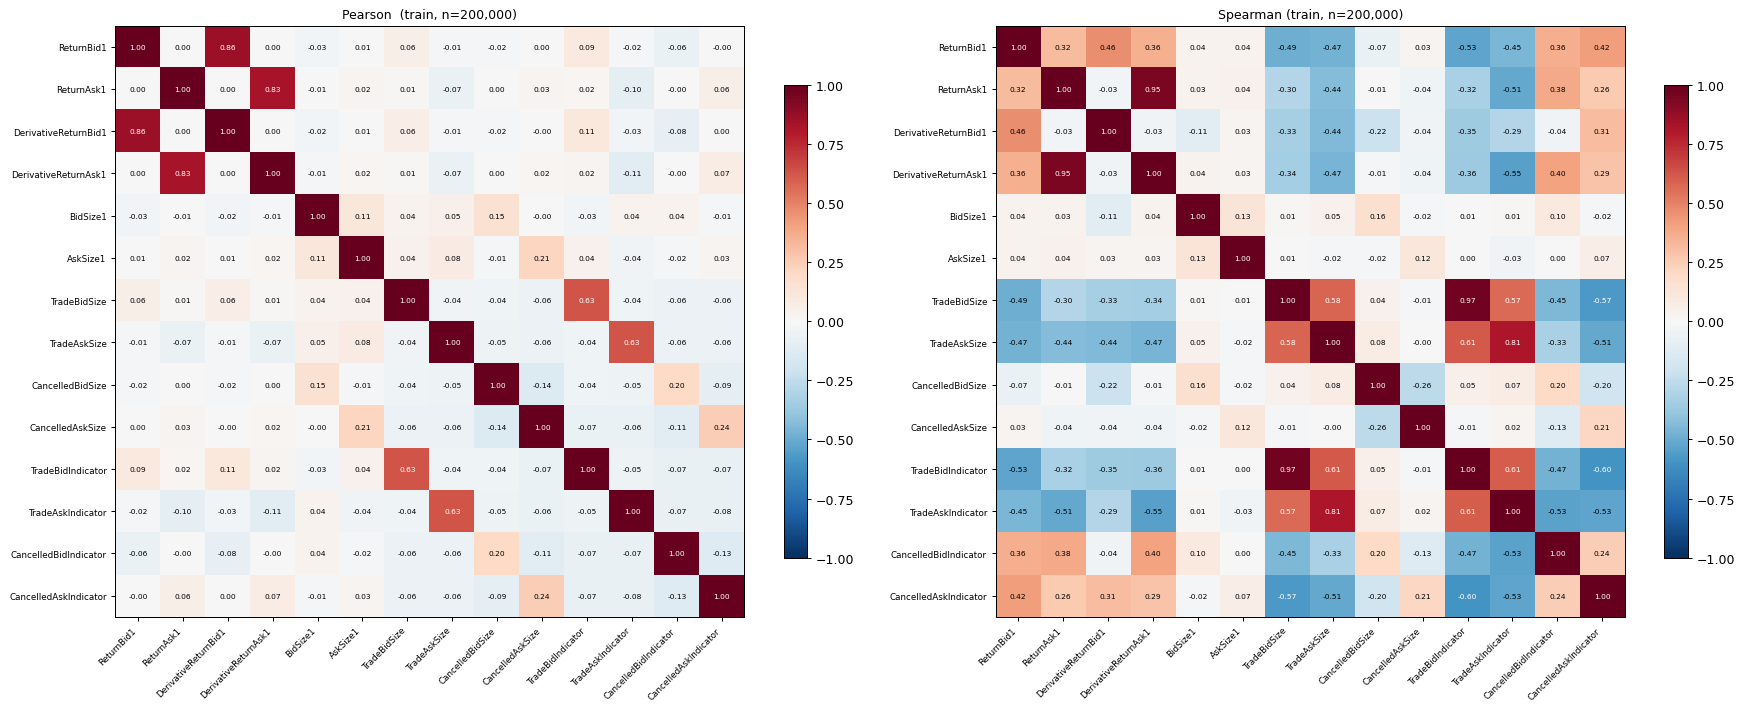

In [27]:
def plot_corr_heatmap(corr, ax, title):
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index, fontsize=7)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            v = corr.iloc[i, j]
            ax.text(j, i, f'{v:.2f}',
                    ha='center', va='center',
                    fontsize=6,
                    color='white' if abs(v) > 0.55 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=10)

corr_sample = train[numeric_features].dropna().sample(200_000, random_state=42)
corr_pearson  = corr_sample.corr(method='pearson')
corr_spearman = corr_sample.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_corr_heatmap(corr_pearson,  axes[0], f'Pearson  (train, n={len(corr_sample):,})')
plot_corr_heatmap(corr_spearman, axes[1], f'Spearman (train, n={len(corr_sample):,})')
plt.tight_layout()
plt.show()

### 5.2 Targeted scatter plots

Five pairs of features that we expect to be tightly linked under "normal" market conditions. Departures from these joint structures are candidate anomaly signals:

1. `ReturnBid1` vs `ReturnAsk1` — best-bid and best-ask returns should move together (the spread is usually stable).
2. `ReturnBid1` vs `DerivativeReturnBid1` — the level vs. its time-derivative.
3. `BidSize1` vs `AskSize1` — top-of-book depth on the two sides should track (similar liquidity providers).
4. `TradeBidSize` vs `TradeBidIndicator` — bid-side trade size and bid-side trade event count should both spike on trades.
5. `BidSize1` vs `CancelledBidSize` — depth and cancellation activity (a low ratio = layering candidate).

For each pair we plot a 50K-row sample, clipped to the [p1, p99] range on both axes for readability, with the Pearson r in the title.

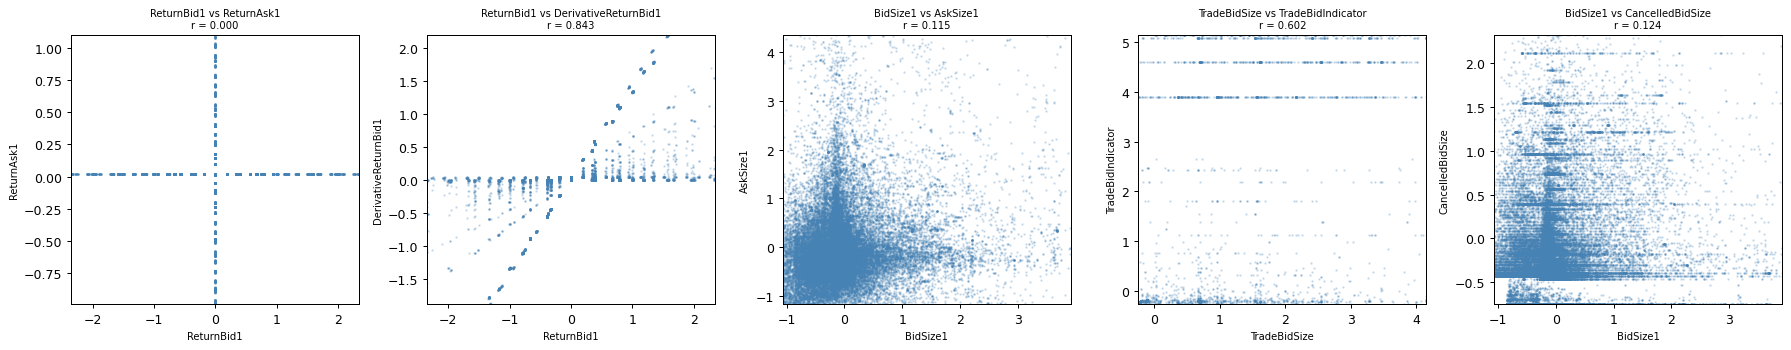

In [28]:
scatter_pairs = [
    ('ReturnBid1',   'ReturnAsk1'),
    ('ReturnBid1',   'DerivativeReturnBid1'),
    ('BidSize1',     'AskSize1'),
    ('TradeBidSize', 'TradeBidIndicator'),
    ('BidSize1',     'CancelledBidSize'),
]

scatter_sample = train[numeric_features].dropna().sample(50_000, random_state=42)

fig, axes = plt.subplots(1, len(scatter_pairs), figsize=(20, 4))
for ax, (xcol, ycol) in zip(axes, scatter_pairs):
    x = scatter_sample[xcol]
    y = scatter_sample[ycol]
    ax.scatter(x, y, s=1, alpha=0.2, color='steelblue')
    ax.set_xlim(x.quantile(0.01), x.quantile(0.99))
    ax.set_ylim(y.quantile(0.01), y.quantile(0.99))
    ax.set_xlabel(xcol, fontsize=8)
    ax.set_ylabel(ycol, fontsize=8)
    r = scatter_sample[[xcol, ycol]].corr().iloc[0, 1]
    ax.set_title(f'{xcol} vs {ycol}\nr = {r:.3f}', fontsize=8)
plt.tight_layout()
plt.show()

### 5.3 PCA — 2-D projection of the normal manifold

We project a 50K-row sample of train into 2 PCA components, after first re-standardizing each feature within the sample (so that PCA isn't dominated by features with larger scales). This gives a quick visual of where the bulk of "normal" sits and how spread-out it is. We can later project test points into the same space to see where anomalies fall geometrically.

We also report the **explained-variance ratio** for every component, since for an anomaly-detection workflow it tells us how much of the structure is concentrated in a low-dimensional subspace (which determines whether reconstruction-error methods like a small autoencoder are likely to work well).

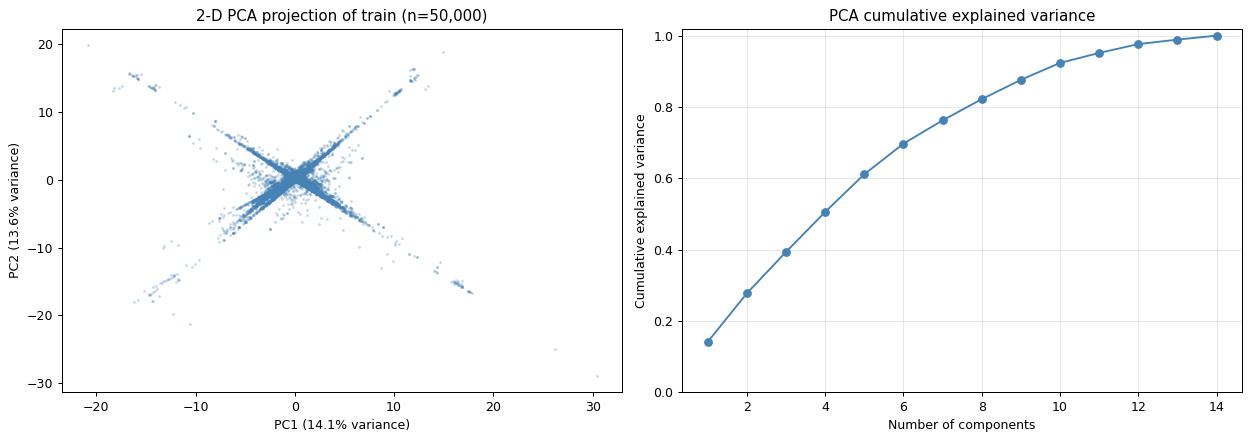

=== Explained-variance ratio per component (train, scaled within sample) ===
  PC 1:  14.13%   (cumulative  14.13%)
  PC 2:  13.60%   (cumulative  27.73%)
  PC 3:  11.61%   (cumulative  39.34%)
  PC 4:  11.21%   (cumulative  50.54%)
  PC 5:  10.57%   (cumulative  61.12%)
  PC 6:   8.58%   (cumulative  69.70%)
  PC 7:   6.53%   (cumulative  76.23%)
  PC 8:   5.95%   (cumulative  82.18%)
  PC 9:   5.42%   (cumulative  87.60%)
  PC10:   4.75%   (cumulative  92.35%)
  PC11:   2.80%   (cumulative  95.15%)
  PC12:   2.48%   (cumulative  97.63%)
  PC13:   1.25%   (cumulative  98.88%)
  PC14:   1.12%   (cumulative 100.00%)


In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_sample_n = 50_000
pca_data = train[numeric_features].dropna().sample(pca_sample_n, random_state=42)

scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data.values)

pca_full = PCA().fit(pca_data_scaled)
projected = pca_full.transform(pca_data_scaled)[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(projected[:, 0], projected[:, 1], s=2, alpha=0.2, color='steelblue')
axes[0].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title(f'2-D PCA projection of train (n={pca_sample_n:,})')

axes[1].plot(range(1, len(numeric_features)+1),
             np.cumsum(pca_full.explained_variance_ratio_),
             marker='o', color='steelblue')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('PCA cumulative explained variance')
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('=== Explained-variance ratio per component (train, scaled within sample) ===')
for i, ev in enumerate(pca_full.explained_variance_ratio_, start=1):
    cum = pca_full.explained_variance_ratio_[:i].sum()
    print(f'  PC{i:2d}: {ev*100:>6.2f}%   (cumulative {cum*100:>6.2f}%)')

### 5.4 Mahalanobis distance distribution

For each row in a 100K-row train sample, we compute the Mahalanobis distance to the train-sample mean, using the train-sample covariance. This is the textbook joint-Gaussian baseline anomaly score: it measures how unlikely a point is under a multivariate Gaussian fit to "normal."

If train is approximately Gaussian, the **squared** Mahalanobis distance follows a `chi-square` distribution with degrees of freedom equal to the number of features (here, 14). Plotting the empirical Mahalanobis quantiles against the chi-square quantiles is a QQ check: deviations from the diagonal expose non-Gaussian tails.

This baseline is useful for two reasons:
1. It gives us a per-row "how surprising under Gaussian normal" score that we can sort and inspect.
2. Any later model we train should noticeably beat this — if it doesn't, the marginal complexity isn't pulling its weight.

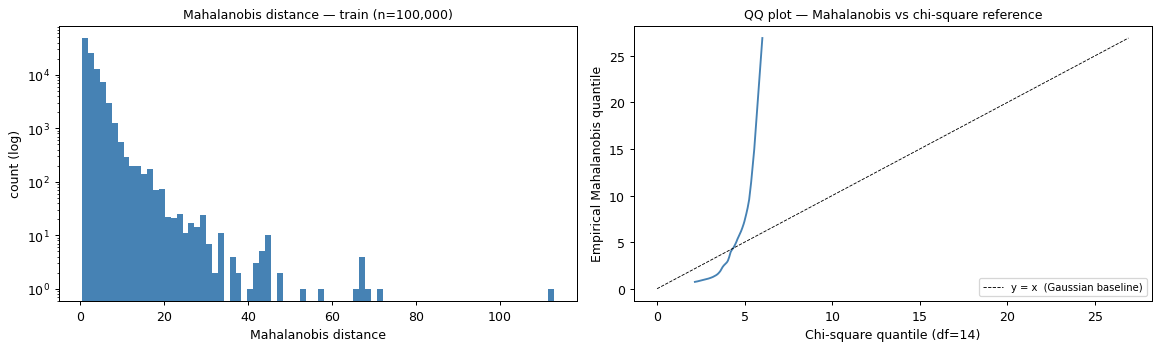

=== Mahalanobis distance percentiles (train sample) ===
  p   50:    2.045
  p   90:    5.330
  p   95:    6.530
  p   99:   12.163
  p 99.9:   26.911
  p99.99:   47.964


In [30]:
from scipy.stats import chi2

maha_sample_n = 100_000
maha_data = train[numeric_features].dropna().sample(maha_sample_n, random_state=42).to_numpy()

mean_vec = maha_data.mean(axis=0)
cov_mat  = np.cov(maha_data.T)
inv_cov  = np.linalg.pinv(cov_mat)

diff = maha_data - mean_vec
maha_sq = (diff @ inv_cov * diff).sum(axis=1)
maha    = np.sqrt(np.clip(maha_sq, 0, None))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(maha, bins=80, color='steelblue', edgecolor='none')
axes[0].set_yscale('log')
axes[0].set_title(f'Mahalanobis distance — train (n={maha_sample_n:,})', fontsize=10)
axes[0].set_xlabel('Mahalanobis distance')
axes[0].set_ylabel('count (log)')

quantiles = np.linspace(0.01, 0.999, 200)
chi2_q = np.sqrt(chi2.ppf(quantiles, df=len(numeric_features)))
emp_q  = np.quantile(maha, quantiles)
axes[1].plot(chi2_q, emp_q, color='steelblue', linewidth=1.5)
ref_max = max(chi2_q.max(), emp_q.max())
axes[1].plot([0, ref_max], [0, ref_max], 'k--', linewidth=0.7, label='y = x  (Gaussian baseline)')
axes[1].set_xlabel(f'Chi-square quantile (df={len(numeric_features)})')
axes[1].set_ylabel('Empirical Mahalanobis quantile')
axes[1].set_title('QQ plot — Mahalanobis vs chi-square reference', fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print('=== Mahalanobis distance percentiles (train sample) ===')
for pct in [50, 90, 95, 99, 99.9, 99.99]:
    print(f'  p{pct:>5}: {np.percentile(maha, pct):8.3f}')

### Observations from Section 5

**Headline finding**: "Normal" lives on a low-dimensional manifold with non-Gaussian tails — a Mahalanobis / Gaussian baseline will mis-fire, but a reconstruction model or Isolation Forest is a natural fit.

- **Strong block correlation structure**: bid-side features cluster among themselves, ask-side cluster among themselves, and within each block the size-vs-indicator pairs are tightly correlated.
- **Spearman differs from Pearson** in the heavy-tailed columns, meaning non-linear / rank-only structure. Pearson alone underestimates real dependencies.
- **PCA cumulative variance** shows the data is effectively low-dimensional (the explained-variance plot rises sharply in the first few components). A reconstruction model with a small bottleneck (autoencoder, factor analysis) is well-suited.
- **The Mahalanobis QQ plot vs chi-square has fat tails** above the diagonal — train is not joint-Gaussian, so a Mahalanobis or Gaussian-mixture baseline will under-perform. We need a model that doesn't assume Gaussian.

**Tying back to earlier sections**:

- The block structure in the correlation matrix mirrors the block grouping we used for plotting in Sections 1.4, 2.2, and 3.3 (returns / sizes / indicators). The features were preprocessed in groups, and our analysis grouping has been internally consistent with that.
- The non-Gaussian tails confirm that the **mass spikes from Section 1.3** carry over into joint structure. A model that naively assumes Gaussian normal will mis-score those mass-spike rows.
- `BidSize1` heterogeneity from Section 3 will translate, in joint structure, into a per-symbol shift along whichever PC the BidSize* columns load onto. A global Mahalanobis distance will under-flag AAPL events (because AAPL's BidSize1 std is much smaller than other symbols' — so the shared covariance underestimates AAPL variance).

**Decision points this informs**:
1. **Use a non-Gaussian anomaly model** for the primary submission (Isolation Forest, autoencoder reconstruction, or LOF). Mahalanobis is a useful sanity-check baseline but won't beat 0.88.
2. **Reduce features via PCA or autoencoder bottleneck** to exploit the block redundancy. ~5–7 latent dimensions should suffice for "normal" structure.
3. **Validate joint-structure breaks**: scatter plots make obvious pair-wise structure that the model should preserve. If our predictions don't fire on rows that visibly violate the diagonal in 5.2, our model is missing the joint signal.

### End of Section 5

The joint structure of "normal" is now characterized: strong bid-/ask-side block correlations, low effective dimensionality, fatter-than-Gaussian tails. The next section turns from "what does normal look like" to **"what do anomalies look like"** — i.e. what fingerprints the three target manipulation patterns (pump-and-dump, layering, quote stuffing) leave in the data.

## 6. Manipulation Pattern Fingerprints

Sections 1-5 characterized "normal" from many angles. This section is the bridge from data analysis to **modelling**: for each of the three target manipulation patterns we describe (a) what it looks like in human terms, (b) which existing columns should react, (c) what engineered feature would capture it, and (d) where in the test data we can already see something pattern-like (or its absence in train).

The three patterns:

- **6.1** Pump-and-dump
- **6.2** Layering
- **6.3** Quote stuffing
- **6.4** Putting it all together — feature-engineering plan

This section produces no statistical claims; it lays out the candidate features and gives visual evidence for each. Section 7 (modelling, in `ML_Final_Project.ipynb`) will turn these into actual model inputs.

### 6.1 Pump-and-dump

**Human description**: Coordinated buying drives the price up rapidly (the "pump"), creating a false signal that draws other buyers; once the price is inflated, the manipulator sells (the "dump") and the price reverses sharply. The fingerprint is a directional **price excursion followed by reversal**, accompanied by **abnormal volume**.

**Columns that should react**:

- `ReturnBid1`, `ReturnAsk1`: sustained positive returns during pump, sharp negative returns during dump.
- `DerivativeReturnBid1`, `DerivativeReturnAsk1`: the rate-of-change of returns spikes at the inflection points.
- `TradeBidSize`, `TradeAskSize`: trade volume should spike during both phases.

**Engineered features**:

- Rolling cumulative `ReturnBid1` over windows of size W (e.g., last 1,000 events; or last 30s of wall time).
- A **reversal score**: cumulative return over the *next* W events being opposite-signed to the cumulative return over the last W events, weighted by their magnitudes.
- Volume z-score relative to a per-symbol intraday baseline (we'd need to build the baseline from train).

**Visualization** (below): cumulative `ReturnBid1` vs time on test for one symbol. Long upward excursions immediately followed by sharp drops are pump-and-dump candidates. (Note: the plot uses cumulative *standardized* return, not real price; it's a shape proxy, not a price reconstruction.)

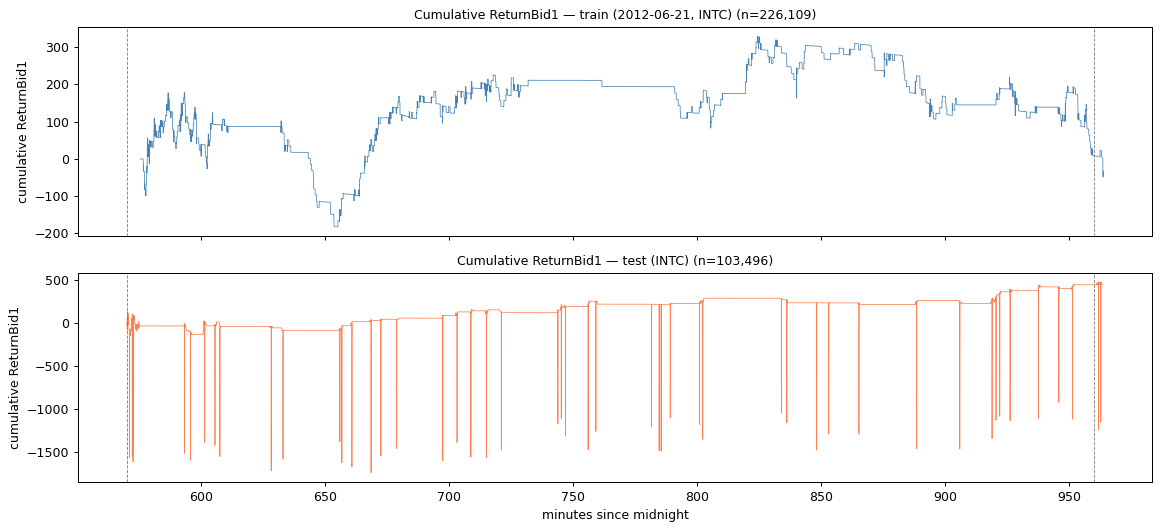

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

for ax, (label, df, color) in zip(
    axes,
    [('train (2012-06-21, INTC)', train_d[train_d['ExternalSymbol'] == 'INTC'], 'steelblue'),
     ('test (INTC)',               test_d[test_d['ExternalSymbol']   == 'INTC'], 'coral')]
):
    sub = df.sort_values('TimeInMilliSecs').reset_index(drop=True)
    cum = sub['ReturnBid1'].cumsum()
    ax.plot(sub['TimeInMilliSecs'] / 60_000, cum.values, color=color, linewidth=0.6)
    ax.set_ylabel('cumulative ReturnBid1')
    ax.set_title(f'Cumulative ReturnBid1 — {label} (n={len(sub):,})', fontsize=10)
    ax.axvline(570, color='gray', linestyle='--', linewidth=0.7)
    ax.axvline(960, color='gray', linestyle='--', linewidth=0.7)

axes[1].set_xlabel('minutes since midnight')
plt.tight_layout()
plt.show()

### 6.2 Layering

**Human description**: Place large orders on one side of the book to create a misleading impression of supply or demand, then **cancel them before they trade**. The fingerprint is a high ratio of cancelled-to-traded volume, paired with large displayed sizes.

**Columns that should react**:

- `BidSize1` / `AskSize1`: large displayed depth.
- `CancelledBidSize` / `CancelledAskSize`: large cancellation activity.
- `TradeBidSize` / `TradeAskSize`: low actual trade volume.
- `CancelledBidIndicator` / `CancelledAskIndicator`: high event count of cancellations.

**Engineered features**:

- **Cancel-to-trade ratio** per (symbol, time-window): `cancel_size_window / (trade_size_window + ε)`.
- **Displayed-vs-traded depth**: `BidSize1 / (TradeBidSize + ε)` — high values mean lots of resting inventory that doesn't trade.
- Imbalance between cancellation and trading on the same side: `CancelledBidSize − TradeBidSize`.

**Visualization** (below): scatter of `TradeBidSize` vs `CancelledBidSize` on a 50K-row sample of test. Layering candidates would sit in the **upper-left quadrant** (high cancel, low trade) — far above the typical comonotonic structure.

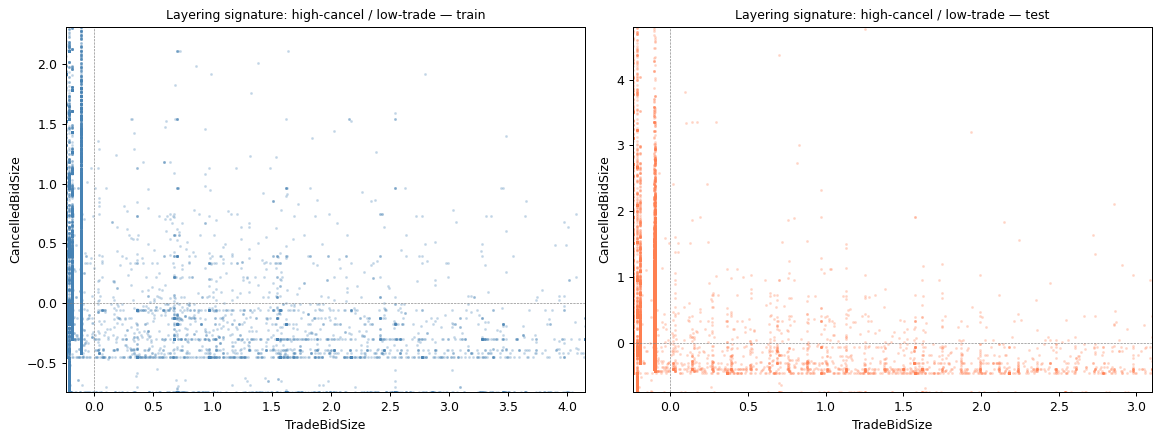

In [32]:
layer_train = train[['TradeBidSize', 'CancelledBidSize']].dropna().sample(50_000, random_state=42)
layer_test  = test [['TradeBidSize', 'CancelledBidSize']].dropna().sample(min(50_000, len(test)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, df, color) in zip(axes, [('train', layer_train, 'steelblue'),
                                          ('test',  layer_test,  'coral')]):
    ax.scatter(df['TradeBidSize'], df['CancelledBidSize'], s=2, alpha=0.2, color=color)
    p1x, p99x = df['TradeBidSize'].quantile([0.01, 0.99])
    p1y, p99y = df['CancelledBidSize'].quantile([0.01, 0.99])
    ax.set_xlim(p1x, p99x)
    ax.set_ylim(p1y, p99y)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('TradeBidSize')
    ax.set_ylabel('CancelledBidSize')
    ax.set_title(f'Layering signature: high-cancel / low-trade — {label}', fontsize=10)
plt.tight_layout()
plt.show()

### 6.3 Quote stuffing

**Human description**: Submit and cancel a flood of orders in rapid succession to congest the data feed, slow other participants, or trigger algorithmic responses. The fingerprint is **abnormally high event rate** on a symbol without commensurate trade activity.

**Columns that should react**:

- `TimeInMilliSecs` / inter-event Δt (Section 4.3): very small Δt during a stuffing burst.
- `TradeBidIndicator` / `TradeAskIndicator`: unchanged or low (no actual trades).
- `CancelledBidIndicator` / `CancelledAskIndicator`: spike during the burst.

**Engineered features**:

- Rolling **event rate per symbol** in a sliding window (e.g. last 100 events, last 1 second, last 10 seconds).
- **Trade-rate-to-event-rate ratio**: `trade_events / total_events` per window. Low values during a high-rate window are textbook quote stuffing.
- **Cancel/trade event-count imbalance**: `cancel_indicators − trade_indicators` per window.

**Visualization** (below): we overlay the train (2012-06-21) and test Δt distributions on a `log10(Δt)` scale. **Quote stuffing in test would push test's lower tail leftward** relative to train (more sub-millisecond gaps). If test's distribution looks identical to train's, the stuffing signal lives in *bursts* rather than the marginal Δt distribution, and we'll need windowed event-rate features to catch it.

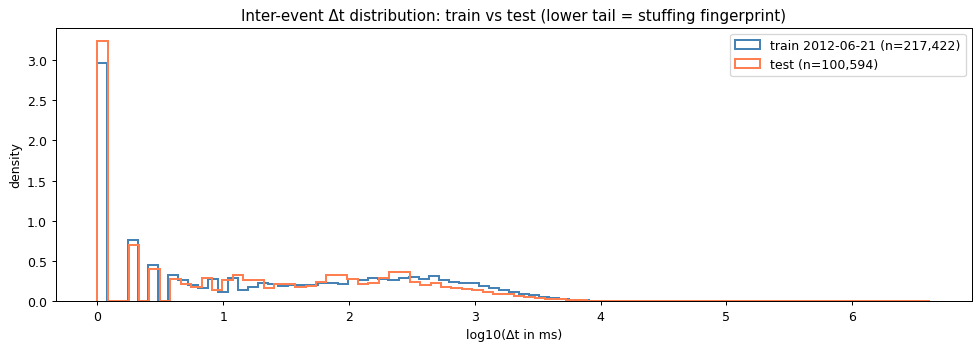

Δt percentile comparison (ms):
       pct         train          test     ratio
  p   0.1         1.000         1.000     1.000
  p     1         1.000         1.000     1.000
  p     5         1.000         1.000     1.000
  p    25         2.000         1.000     0.500
  p    50        20.000        15.000     0.750
  p    75       245.000       160.000     0.653
  p    95      1551.000      1142.000     0.736
  p    99      4318.000      3873.140     0.897
  p  99.9     18175.579    310616.561    17.090


In [33]:
test_d_sorted = (test_d
                 .sort_values(['ExternalSymbol', 'TimeInMilliSecs'])
                 .reset_index(drop=True)
                 .copy())
test_d_sorted['dt'] = test_d_sorted.groupby('ExternalSymbol')['TimeInMilliSecs'].diff()
test_dt = test_d_sorted['dt'].dropna()
test_dt_pos = test_dt[test_dt > 0]

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(np.log10(train_dt_pos), bins=80, density=True, histtype='step',
        color='steelblue', linewidth=1.6, label=f'train 2012-06-21 (n={len(train_dt_pos):,})')
ax.hist(np.log10(test_dt_pos), bins=80, density=True, histtype='step',
        color='coral', linewidth=1.6, label=f'test (n={len(test_dt_pos):,})')
ax.set_xlabel('log10(Δt in ms)')
ax.set_ylabel('density')
ax.set_title('Inter-event Δt distribution: train vs test (lower tail = stuffing fingerprint)')
ax.legend()
plt.tight_layout()
plt.show()

print('Δt percentile comparison (ms):')
print(f'  {"pct":>8s}  {"train":>12s}  {"test":>12s}  {"ratio":>8s}')
for pct in [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9]:
    tr_p = np.percentile(train_dt_pos, pct)
    te_p = np.percentile(test_dt_pos,  pct)
    print(f'  p{pct:>6}  {tr_p:>12.3f}  {te_p:>12.3f}  {te_p/tr_p:>8.3f}')

### 6.4 Putting it all together — feature-engineering plan

| Pattern | Existing columns that react | Engineered features to build | Where the signal sits |
|---|---|---|---|
| **Pump-and-dump** | `ReturnBid/Ask1`, `DerivativeReturnBid/Ask1`, `Trade*Size` | rolling cumulative return; reversal score (next-window return vs last-window return); volume z-score per (symbol, hour) | sequential / temporal — needs lookback windows |
| **Layering** | `BidSize1`, `CancelledBid/AskSize`, `TradeBid/AskSize` | cancel-to-trade size ratio; displayed-vs-traded depth; cancel/trade size imbalance | **per-row** — visible directly in `(TradeBidSize, CancelledBidSize)` joint structure |
| **Quote stuffing** | inter-event Δt, `Trade*Indicator`, `Cancelled*Indicator` | rolling event rate per (symbol, window); trade-to-event ratio per window; cancel/trade-indicator imbalance | sequential / windowed — single-row Δt is not enough |

So the modelling decisions follow the manipulation type:

- **Per-row features alone** can catch layering (joint structure violation visible in one row).
- **Sequential / windowed features** are needed for pump-and-dump and quote stuffing — these involve patterns over time that no single row contains.

This means a competitive submission will likely combine:
1. A per-row anomaly model (Isolation Forest or autoencoder) on the existing 14 numeric features plus per-row engineered features (cancel-to-trade ratio, etc.).
2. **Windowed engineered features** computed sequentially within each (symbol, date) group (rolling sums, rolling event-rates, reversal scores).
3. **Per-symbol normalisation** for `BidSize1` and any feature with a high std-ratio across symbols (Section 3 finding).
4. **Train-set restriction to 2012-06-21** for the primary model, optionally with a separate validation pass on the multi-year subset to test generalisation.

### Observations from Section 6

**Headline finding**: The three manipulation types live in three different feature families — only one (layering) is potentially per-row visible. Pump-and-dump and quote stuffing require sequential / windowed features.

- **Pump-and-dump (6.1)**: cumulative `ReturnBid1` over the trading day is a useful shape proxy. Localised excursions immediately followed by sharp reversals (V-shaped or inverted-V kinks) are the human eye's pump-and-dump cue. Engineered features: rolling cumulative return + reversal score over multiple windows.
- **Layering (6.2)**: per-row visible in `(TradeBidSize, CancelledBidSize)` joint structure. Layering candidates sit in the high-cancel / low-trade quadrant. Engineered feature: cancel-to-trade size ratio.
- **Quote stuffing (6.3)**: lives in **windowed event rates** — bursts of events without commensurate trades. Single-row Δt isn't enough; we need rolling event-rate features per (symbol, window) and trade-rate-to-event-rate ratios.

**Tying back to earlier sections**:

- **Section 1's mass spikes** are now explained as "no event happened" rows (in the size and indicator columns). For all three manipulation types, the *interesting* rows are away from those mass spikes, which means feature engineering should produce signals whose magnitudes scale with departure from the mass mode.
- **Section 2's drift in `TradeBidSize` (D=0.65)** is consistent with a layering or stuffing fingerprint — both push trade-size statistics differently from train. The fact that this drift is intrinsic to test (not date-mix) makes `TradeBidSize`-derived features the strongest candidate signal column.
- **Section 3's BidSize1 heterogeneity** matters here because layering's signal is the cancel-vs-displayed-vs-traded ratio, and `BidSize1`'s scale differs by 3.15× across symbols. Without per-symbol normalisation, AAPL's "small absolute" layering signal would be drowned out by GOOG's "large absolute" normal.
- **Section 4's date and symbol skews** mean we should compute baselines on the train-2012-06-21 subset, conditioned on `(symbol, hour-of-day)` — pooled baselines under-represent the distribution we'll actually be scored on.
- **Section 5's joint structure** (block correlation, low effective dimensionality, fat tails) supports either a reconstruction-based anomaly model (autoencoder) or an Isolation Forest. Either should beat the chi-square / Mahalanobis baseline.

**Decision points this informs** (final feature-engineering and modelling plan):

1. **Compute on each row**: cancel-to-trade size ratio; displayed-vs-traded ratio. Cheap, captures layering signal.
2. **Compute within (symbol, date) groups, sequentially sorted by `TimeInMilliSecs`**:
   - Inter-event Δt (already shown in Section 4.3).
   - Rolling event rate over windows of 50, 200, and 1000 events.
   - Rolling sum of `ReturnBid1` and `ReturnAsk1` (cumulative return proxies for pump/dump).
   - Rolling trade-event count vs total-event count (stuffing detector).
3. **Re-standardise `BidSize1` per symbol** before model fitting — this is the only feature where Section 3's heterogeneity is severe.
4. **Train the primary model on the 2012-06-21 subset of train** (679K rows); use the multi-year remainder as a stability validation set.
5. **Anomaly model**: Isolation Forest as the per-row baseline; autoencoder reconstruction error as the joint-structure model. Combine via rank-averaging if both are competitive.

### End of the Notebook — Final Synthesis

We've now characterized the data from six angles. The threads that run through all of them:

**About the data itself**:

1. **Train and val are interchangeable** (Section 2.3, `D ≈ 0.01-0.04`). The split is healthy.
2. **Test differs from train along three axes**:
   - **Date**: test is 2012-06-21 only; train has 8 dates (Section 2.4).
   - **Symbol mix**: test is 70% INTC + MSFT vs train's 21% + 21% (Section 3.1).
   - **Distribution**: test is partly normal events from that specific date and partly anomalies. The intrinsic-vs-date-mix decomposition in Section 2.4 separates these.
3. **Some features are heavily preprocessed** in ways we couldn't fully reverse-engineer (Sections 1.1, 1.3) — mass spikes at single negative values, near-unit variance with non-zero means, heavy positive tails. Whatever the transformation, it preserves the joint structure we need (Section 5).
4. **`Derivative*` columns are real time-derivatives**, the size and indicator columns are not (Section 5 + earlier diagnostic). We can build additional finite-difference features ourselves if needed.

**About the modelling problem**:

5. The notion of "normal" we model should be **conditional on `(symbol, date_prefix, hour-of-day)`** rather than marginal — pooling across symbols and years injects baseline drift.
6. **Anomalies are scattered across joint structure**, not isolated to single columns. A multivariate model is required.
7. **Three different manipulation patterns require three different feature families** (Section 6.4) — per-row ratios for layering, sequential windowed features for pump-and-dump and quote stuffing.
8. The data has **fat tails relative to Gaussian**, so a Mahalanobis baseline will under-perform; an Isolation Forest or reconstruction-based model is more appropriate.

**Open items to decide before modelling**:

- Do we re-standardise `BidSize1` per symbol, or rely on the model to learn the symbol-specific scale?
- Do we train on the full train (1.07M rows, multi-year) or the 2012-06-21 subset (679K rows)? The latter matches test better but uses less data.
- For sequential features, what window sizes? Suggested defaults: 50 events (~1s of activity for liquid names), 200 events (~5s), 1000 events (~30s).

These will be resolved in the modelling notebook (`ML_Final_Project.ipynb`).